=== PLOTTING ELECTRON GRAPHS ===


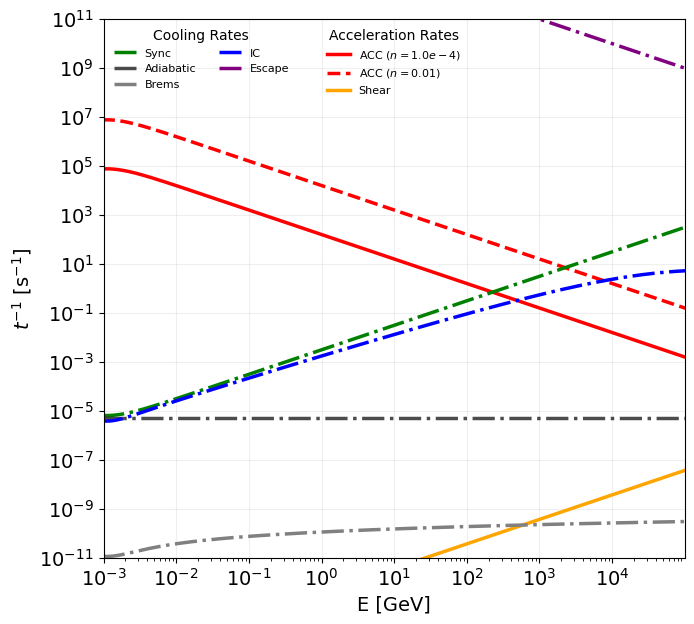

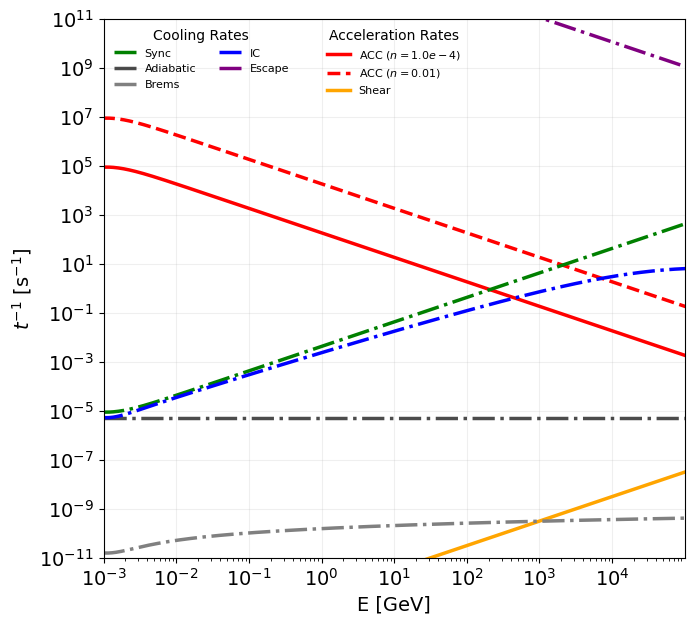

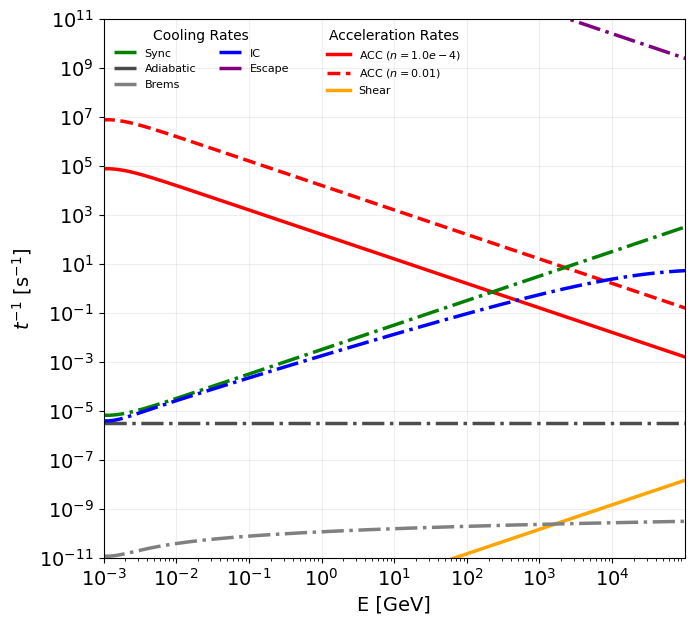

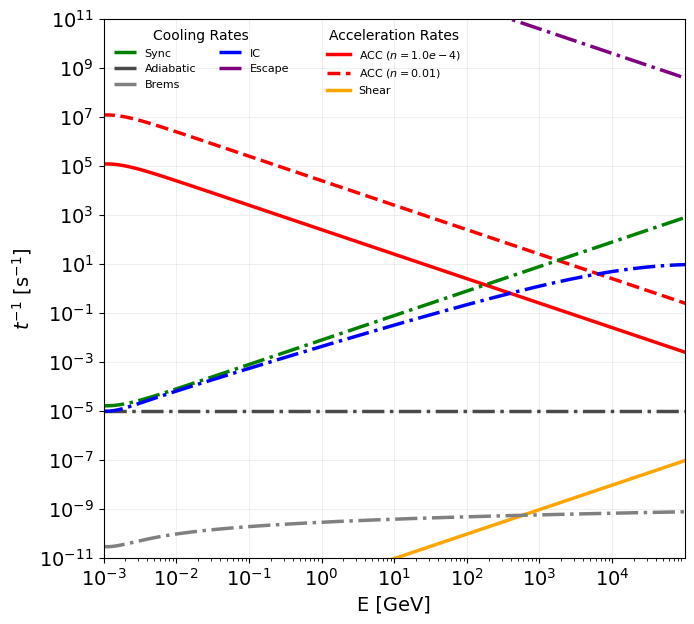

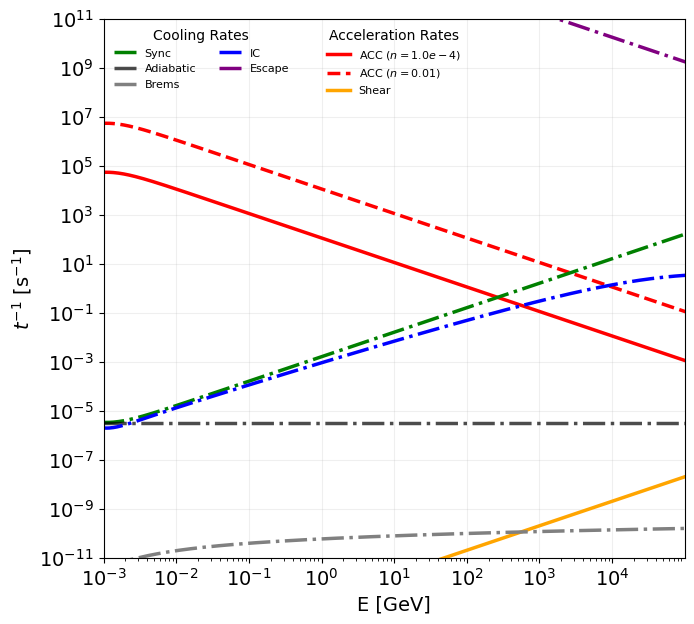

...

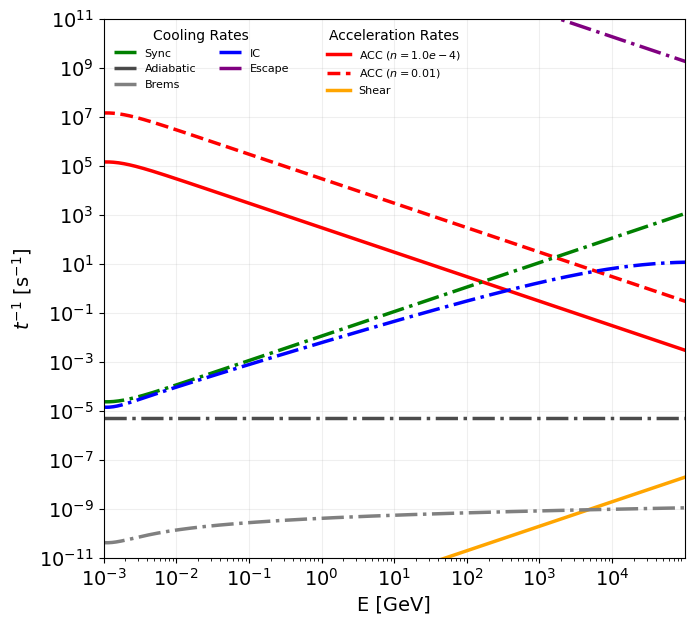

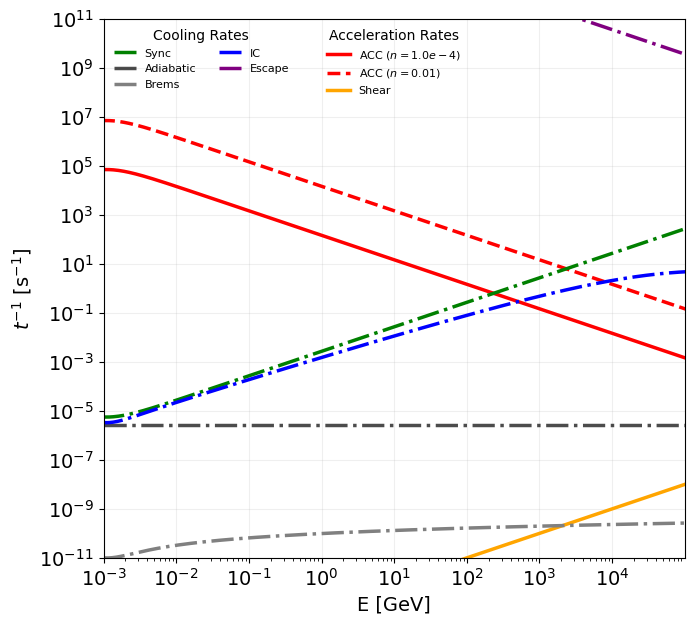

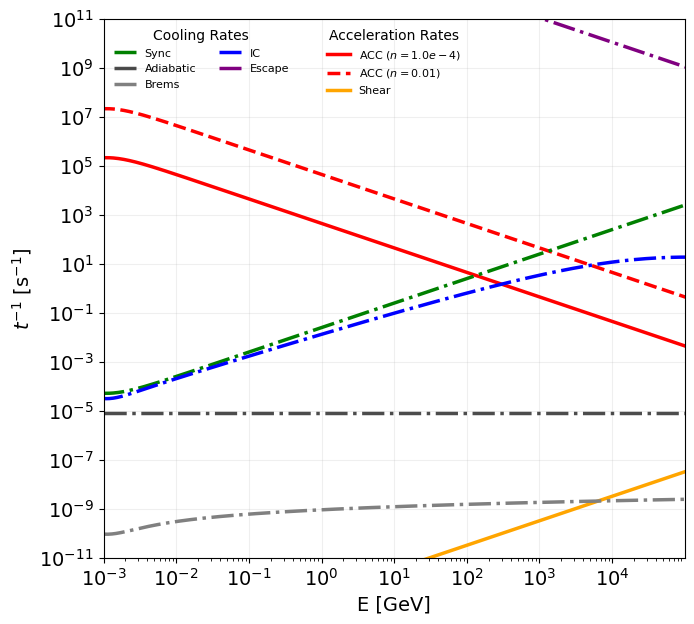

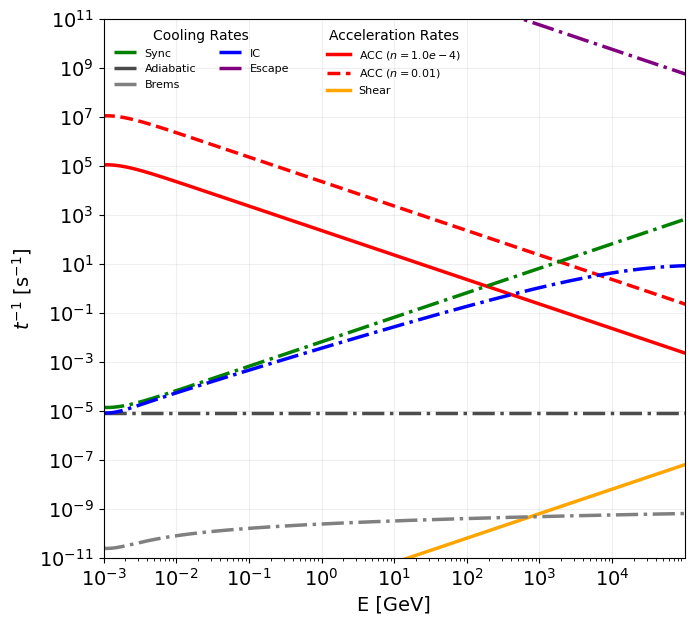

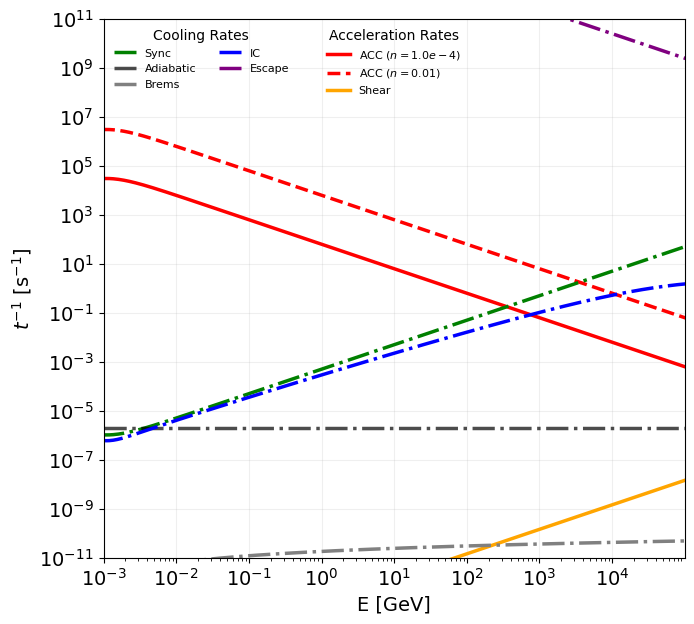

In [1]:
print("=== PLOTTING ELECTRON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

source_file = "source.txt"
source_list = []

try:
    with open(source_file, mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            source_list.append(row)
except FileNotFoundError:
    print(f"ERROR: File '{source_file}' not found.")

for params in source_list:
    source_name = params['name']
    filename = f"data/{source_name}_electrons.csv"
    
    # 1. Resgatando os valores de n do seu source.txt
    # Usamos o .get() com um valor padrão para evitar que o código quebre 
    # caso alguma linha antiga do txt não tenha o n_2 ainda.
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')
    
    E_GeV_ele, rate_acc, rate_acc_2, rate_sync, rate_bremss, rate_ic0, rate_ic1 = [], [], [], [], [], [], []
    rate_shear_ele, rate_esc_ele = [], [] 
    t_ad_val = 0
    
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_ele.append(float(row['E_GeV']))
                rate_acc.append(float(row['rate_acc']))
                rate_acc_2.append(float(row['rate_acc_2']))
                rate_sync.append(float(row['rate_sync']))
                rate_bremss.append(float(row['rate_bremss']))
                rate_ic0.append(float(row['rate_ic_0']))
                rate_ic1.append(float(row['rate_ic_1']))
                rate_shear_ele.append(float(row['Shear'])) 
                rate_esc_ele.append(float(row['ESC']))     
                t_ad_val = float(row['t_ad_val']) 
    except FileNotFoundError:
        print(f"ERROR: File '{filename}' not found.")
        continue

    plt.figure(figsize=(7.5, 7))

    # 2. Inserindo os valores dinamicamente nas labels usando f-strings
    # O Matplotlib entende o $...$ para renderizar a fonte matemática bonitinha
    line_acc, = plt.loglog(E_GeV_ele, rate_acc, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
    line_acc2, = plt.loglog(E_GeV_ele, rate_acc_2, label=f'ACC ($n={n_2_val}$)', color='red', linestyle='--', linewidth=2.5)
    
    line_shear, = plt.loglog(E_GeV_ele, rate_shear_ele, label='Shear', color='orange', linestyle='-', linewidth=2.5)
    
    # Curvas de Resfriamento/Fuga
    line_sync, = plt.loglog(E_GeV_ele, rate_sync, label='Sync', color='green', linestyle='dashdot', linewidth=2.5)
    line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='dashdot', alpha=0.7, linewidth=2.5)
    line_brems, = plt.loglog(E_GeV_ele, rate_bremss, label='Brems', color='grey', linestyle='dashdot', linewidth=2.5)
    line_ic1, = plt.loglog(E_GeV_ele, rate_ic1, label='IC', color='blue', linestyle='dashdot', markerfacecolor='none', linewidth=2.5)
    line_esc, = plt.loglog(E_GeV_ele, rate_esc_ele, label='Escape', color='purple', linestyle='dashdot', linewidth=2.5)
    
    # Atualização da legenda
    leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper center', fontsize=8, frameon=False)
    plt.gca().add_artist(leg_acc) 
    leg_cool = plt.legend(handles=[line_sync, line_ad, line_brems, line_ic1, line_esc], title='Cooling Rates', loc='upper left', fontsize=8, frameon=False, ncol=2)
    
    plt.xlabel('E [GeV]', fontsize=14)
    plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
    plt.xlim(1e-3, 1e5)
    plt.ylim(1e-11, 1e11)
    
    plt.xticks([10.0**i for i in range(-3, 5, 1)])
    plt.yticks([10.0**i for i in range(-11, 12, 2)])
    plt.tick_params(axis='both', which='major', labelsize=14)
        
    plt.grid(True, which="major", ls="-", alpha=0.2)
    
    os.makedirs("image", exist_ok=True)
    
    plt.savefig(f"image/{source_name}_electrons.png", bbox_inches='tight')
    plt.show()

=== PLOTTING PROTON GRAPHS ===


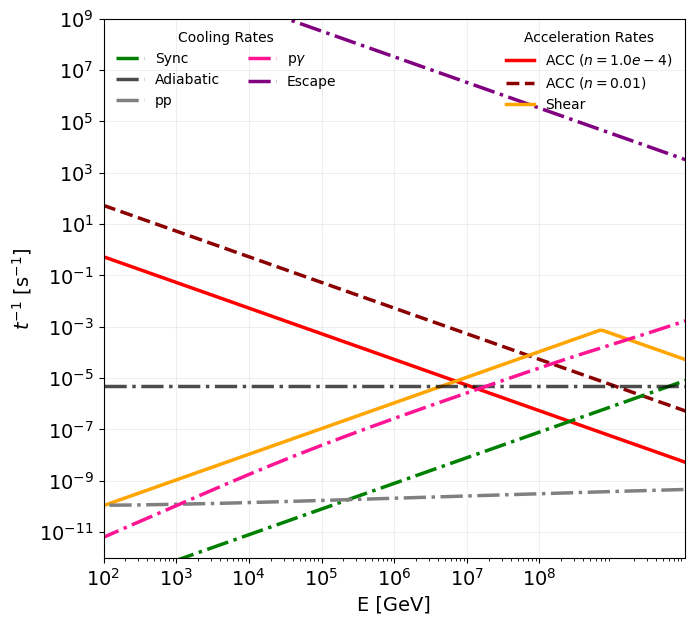

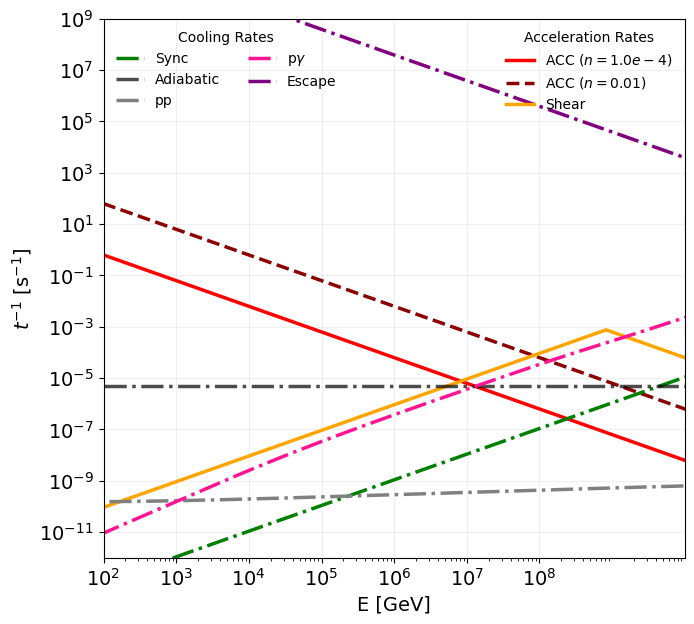

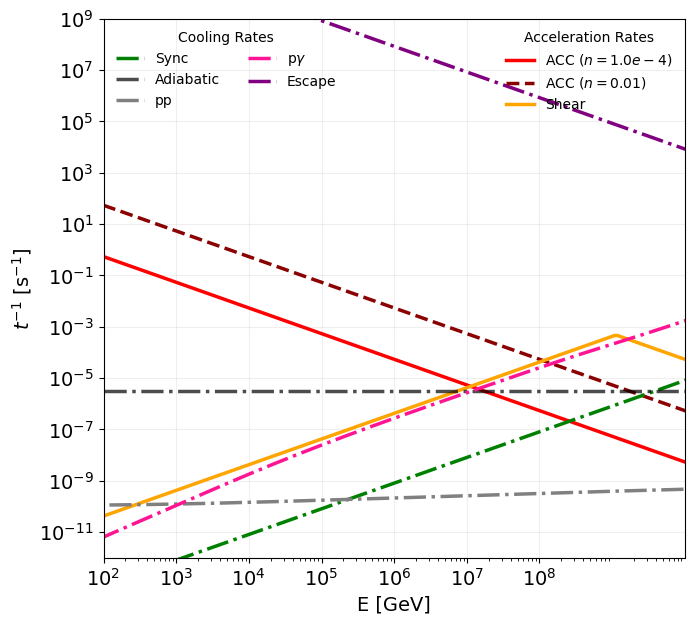

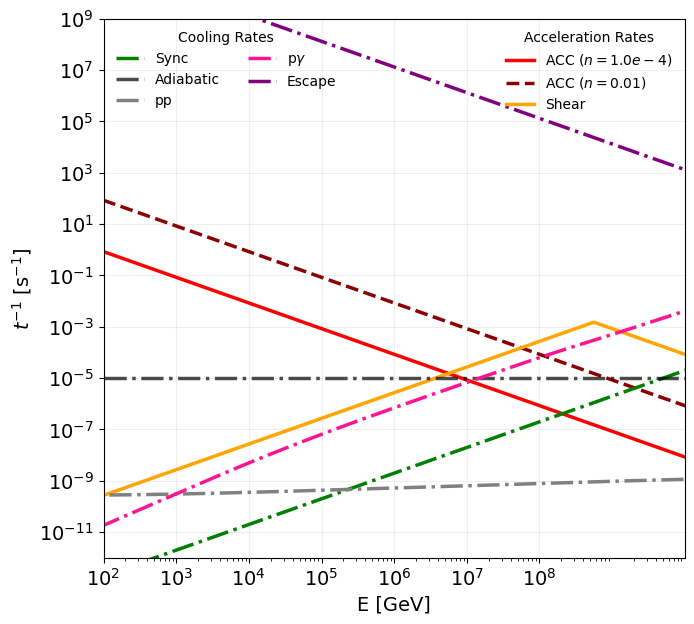

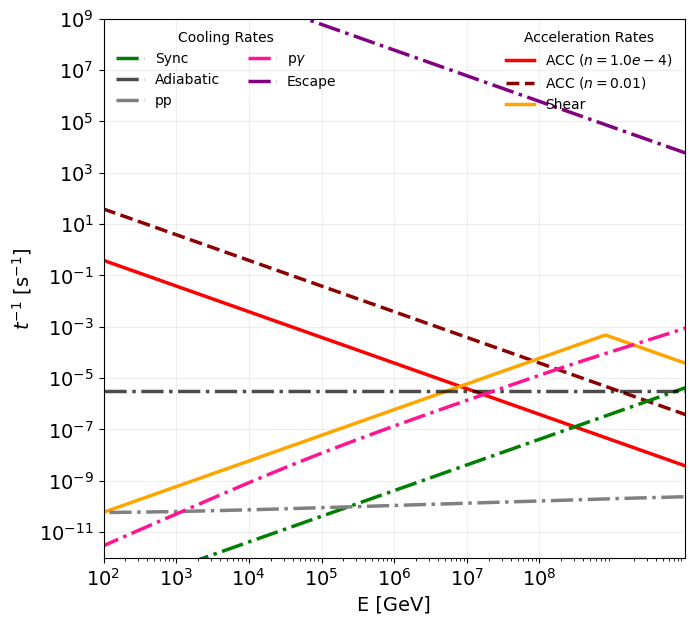

...

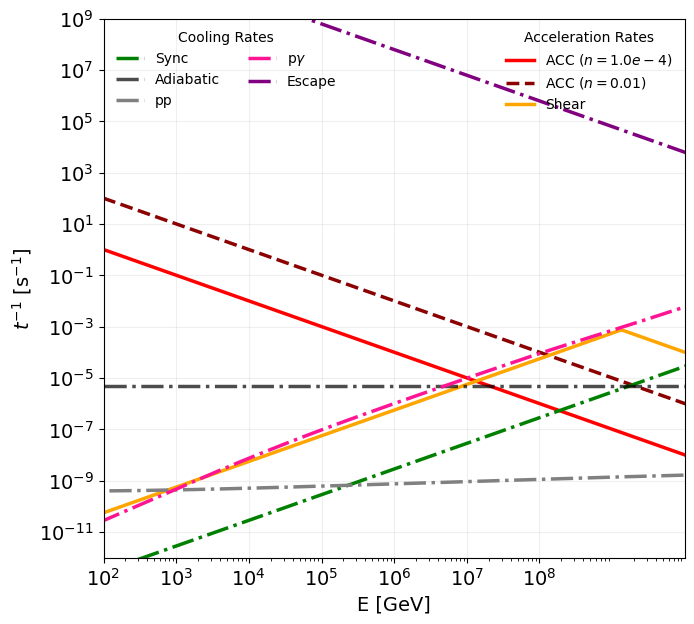

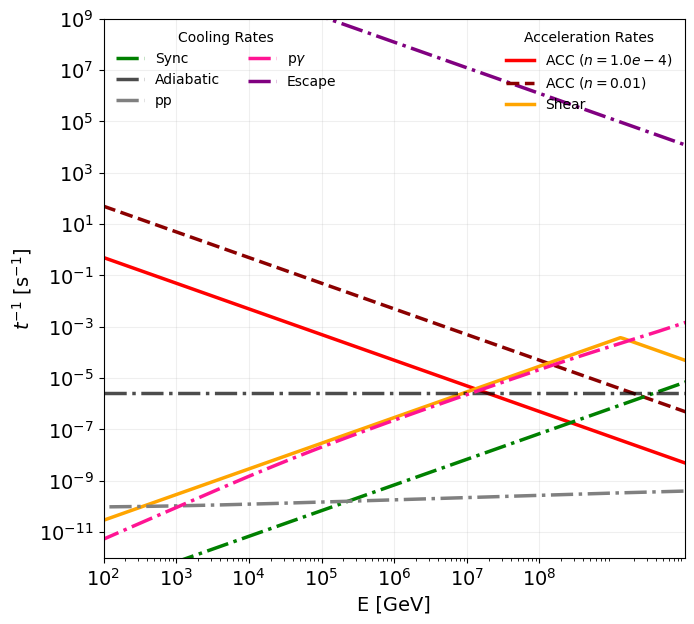

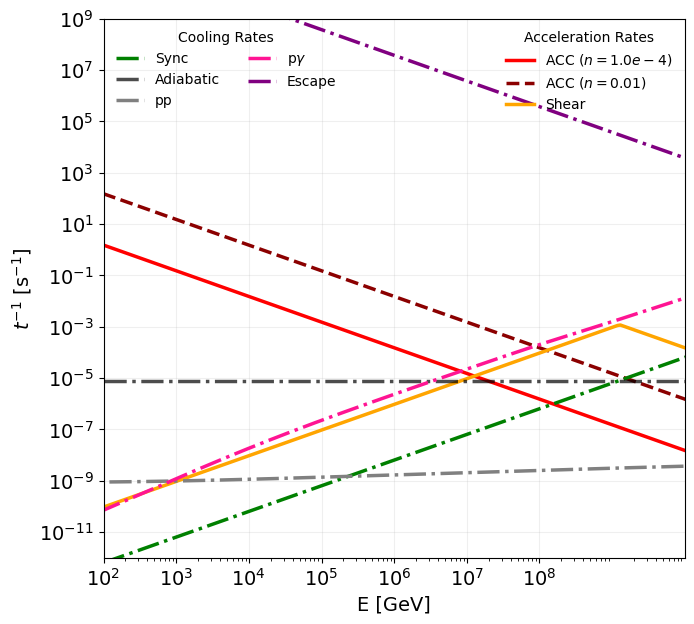

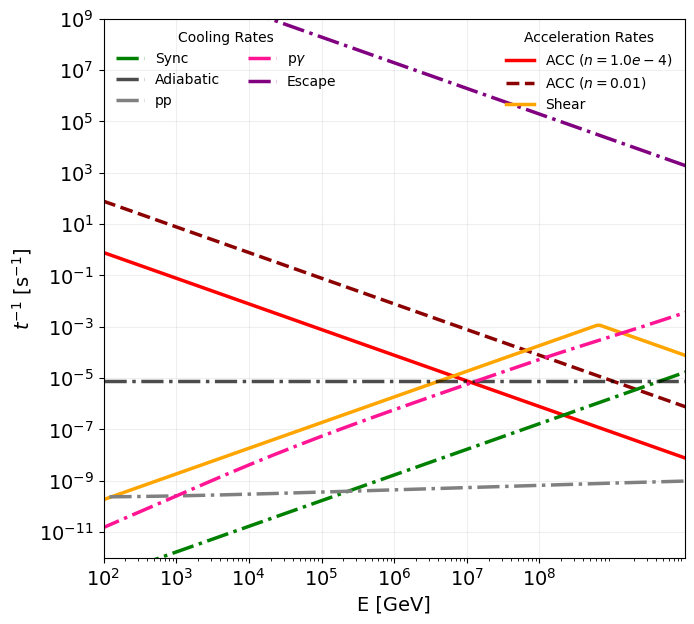

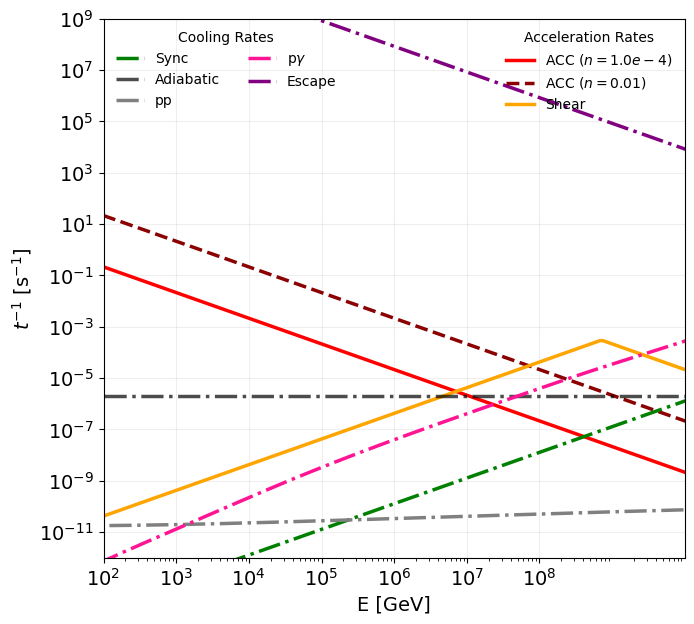

In [2]:
print("=== PLOTTING PROTON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# Garante que a pasta existe para não dar erro no savefig
os.makedirs("image", exist_ok=True)

for params in source_list:
    source_name = params['name']
    filename = f"data/{source_name}_protons.csv"
    
    # 1. Resgatando os valores de n para as legendas
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')
    
    # 2. Inicializando a nova lista rate_acc_pro_2
    E_GeV_pro, rate_acc_pro, rate_acc_pro_2, rate_sync_pro, rate_pp, rate_pg = [], [], [], [], [], []
    rate_shear_pro, rate_esc_pro = [], [] 
    t_ad_val = 0
    
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_pro.append(float(row['E_prime_GeV']))
                rate_acc_pro.append(float(row['rate_acc']))
                
                # 3. Lendo a nova taxa de aceleração do CSV
                rate_acc_pro_2.append(float(row['rate_acc_2']))
                
                rate_sync_pro.append(float(row['rate_sync']))
                rate_pp.append(float(row['rate_pp']))
                rate_pg.append(float(row['rate_pg']))
                rate_shear_pro.append(float(row['Shear'])) 
                rate_esc_pro.append(float(row['ESC']))     
                t_ad_val = float(row['t_ad_val'])
                
        plt.figure(figsize=(7.5, 7))
        
        # 4. Curvas de Aceleração (Original e Alternativa) com f-strings
        line_acc, = plt.loglog(E_GeV_pro, rate_acc_pro, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
        line_acc2, = plt.loglog(E_GeV_pro, rate_acc_pro_2, label=f'ACC ($n={n_2_val}$)', color='darkred', linestyle='--', linewidth=2.5)
        line_shear, = plt.loglog(E_GeV_pro, rate_shear_pro, label='Shear', color='orange', linestyle='-', linewidth=2.5)
        
        # Curvas de Resfriamento/Fuga
        line_sync, = plt.loglog(E_GeV_pro, rate_sync_pro, label='Sync', color='green', linestyle='-.', linewidth=2.5)
        line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='-.', alpha=0.7, linewidth=2.5)
        line_pp, = plt.loglog(E_GeV_pro, rate_pp, label='pp', color='grey', linestyle='-.', linewidth=2.5)
        line_pg, = plt.loglog(E_GeV_pro, rate_pg, label='p$\gamma$', color='deeppink', linestyle='-.', linewidth=2.5)
        line_esc, = plt.loglog(E_GeV_pro, rate_esc_pro, label='Escape', color='purple', linestyle='-.', linewidth=2.5)

        # 5. Atualização da legenda de aceleração incluindo line_acc2
        leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper right', fontsize=10, frameon=False)
        plt.gca().add_artist(leg_acc) 
        leg_cool = plt.legend(handles=[line_sync, line_ad, line_pp, line_pg, line_esc], title='Cooling Rates', loc='upper left', fontsize=10, frameon=False, ncol=2)

        plt.xlabel('E [GeV]', fontsize=14)
        plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
        plt.xlim(1e2, 1e10)
        plt.ylim(1e-12, 1e9)
        
        plt.xticks([10.0**i for i in range(2, 9, 1)])
        plt.yticks([10.0**i for i in range(-11, 10, 2)])
        plt.tick_params(axis='both', which='major', labelsize=14)
            
        plt.grid(True, which="major", ls="-", alpha=0.2)
        
        # O bbox_inches='tight' evita que a legenda fique cortada ao salvar
        plt.savefig(f"image/{source_name}_protons.png", bbox_inches='tight')
        plt.show()
        
    except FileNotFoundError:
        print(f"File {filename} not found for plotting.")

=== PLOTTING ALL PROCESSES (LINES & CUSTOM LIMITS) ===


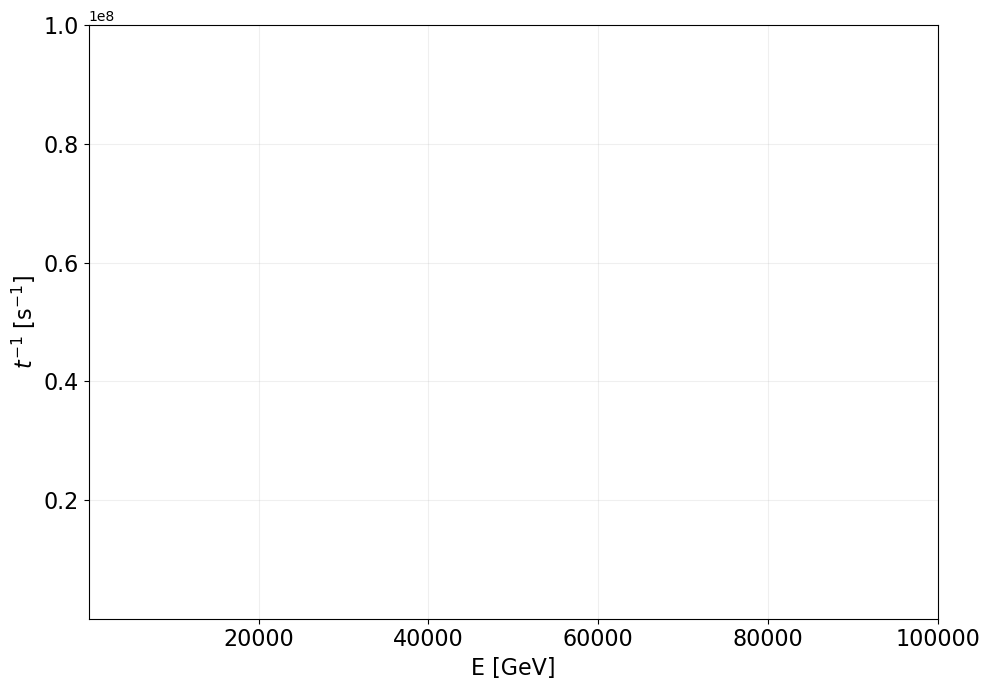

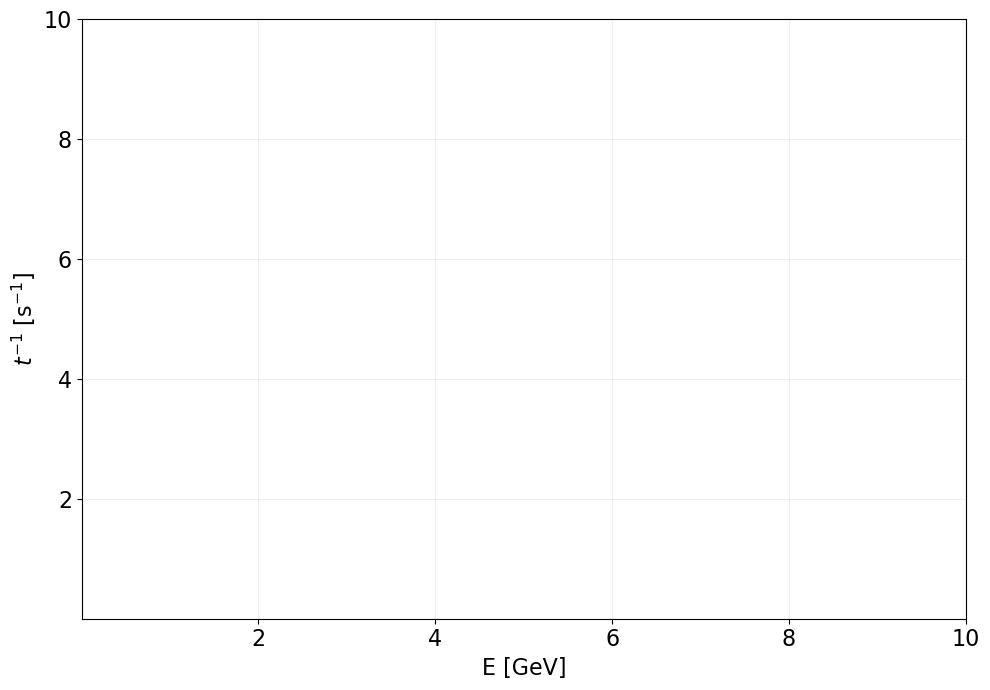

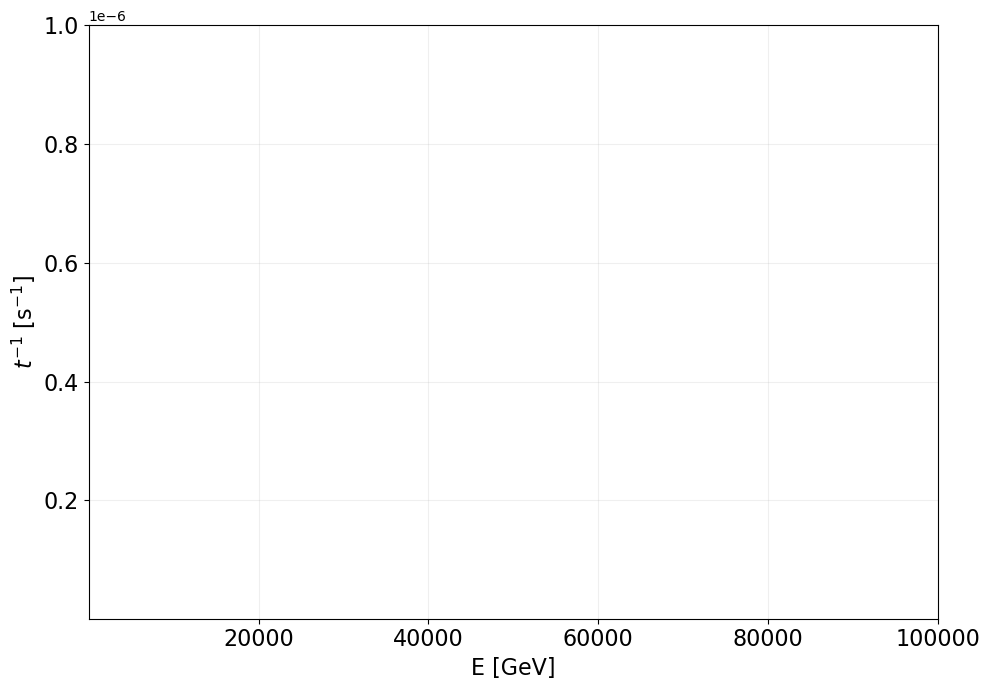

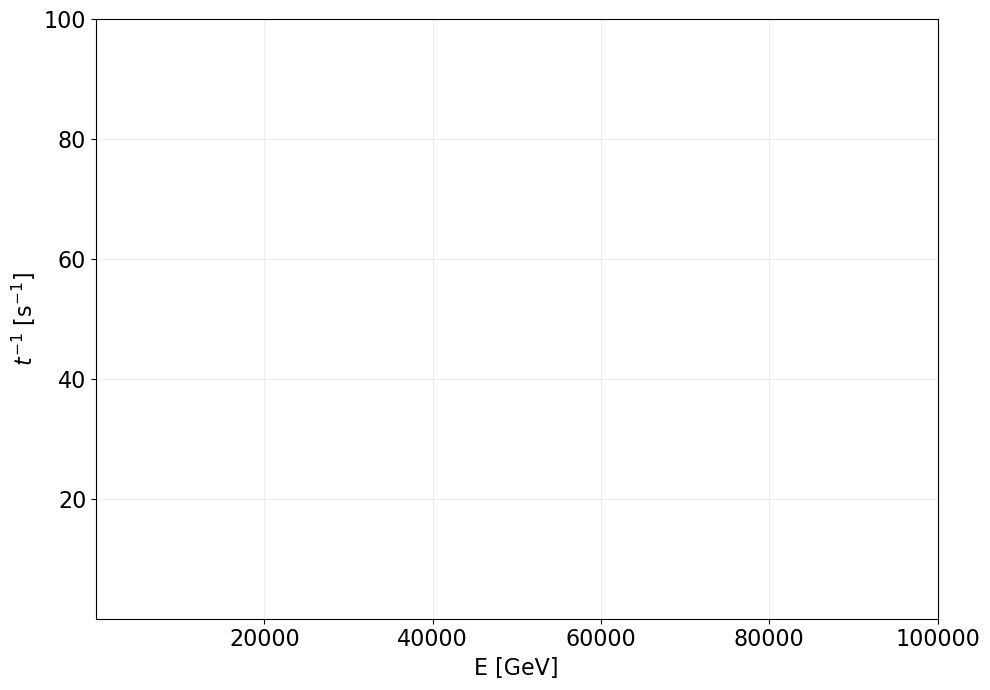

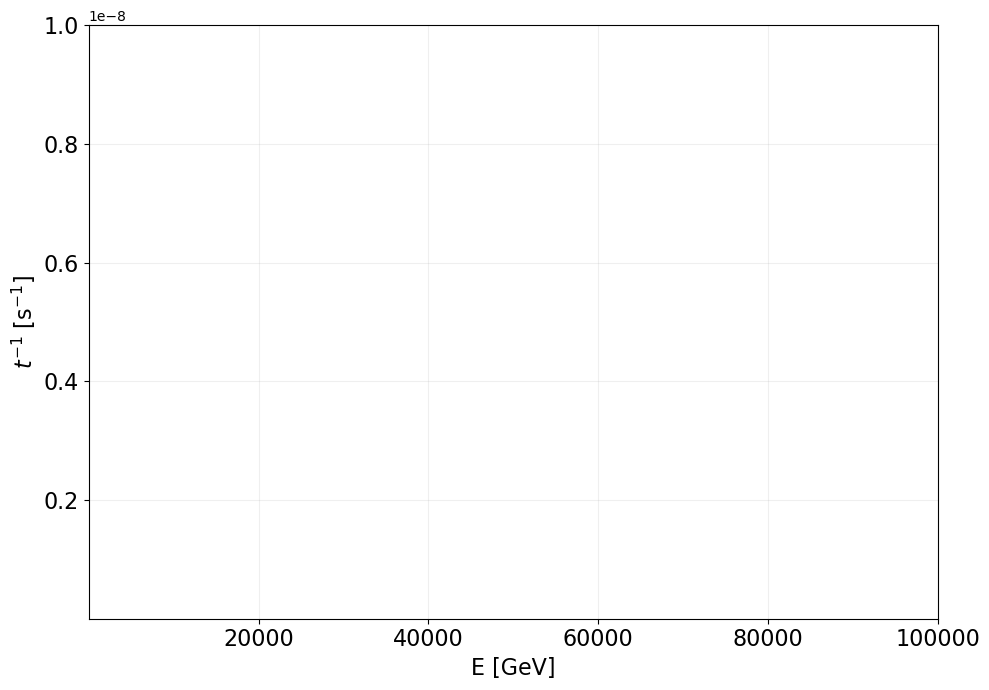

...

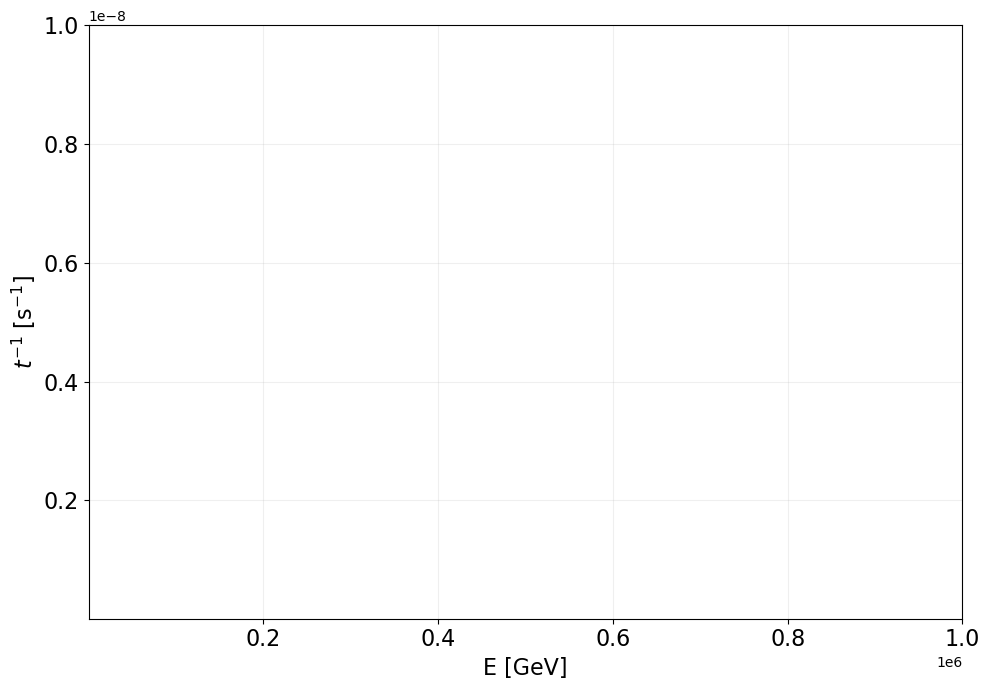

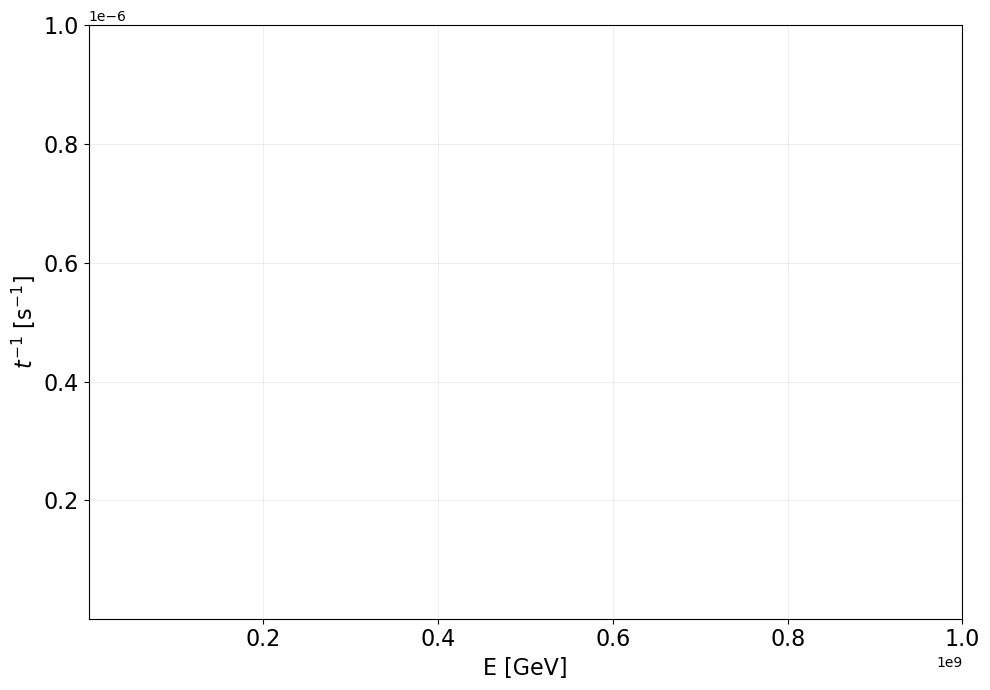

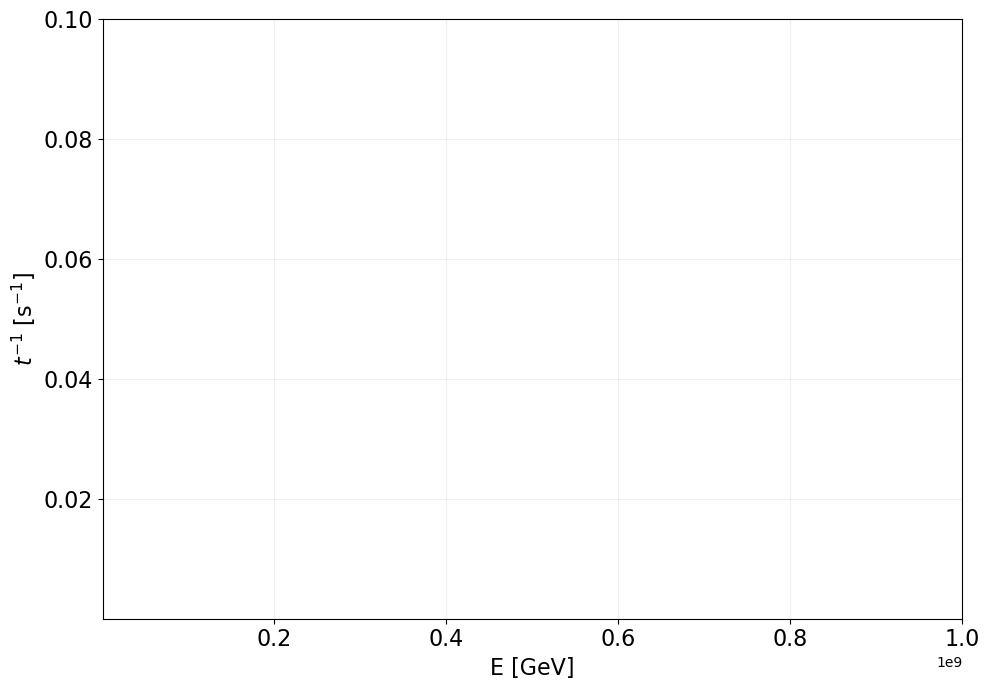

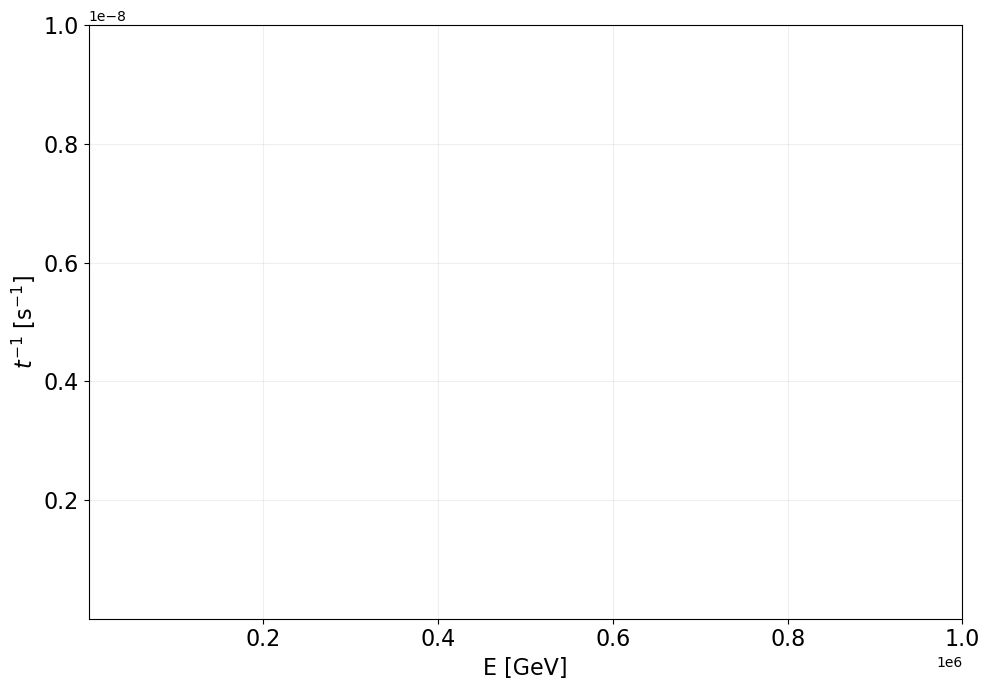

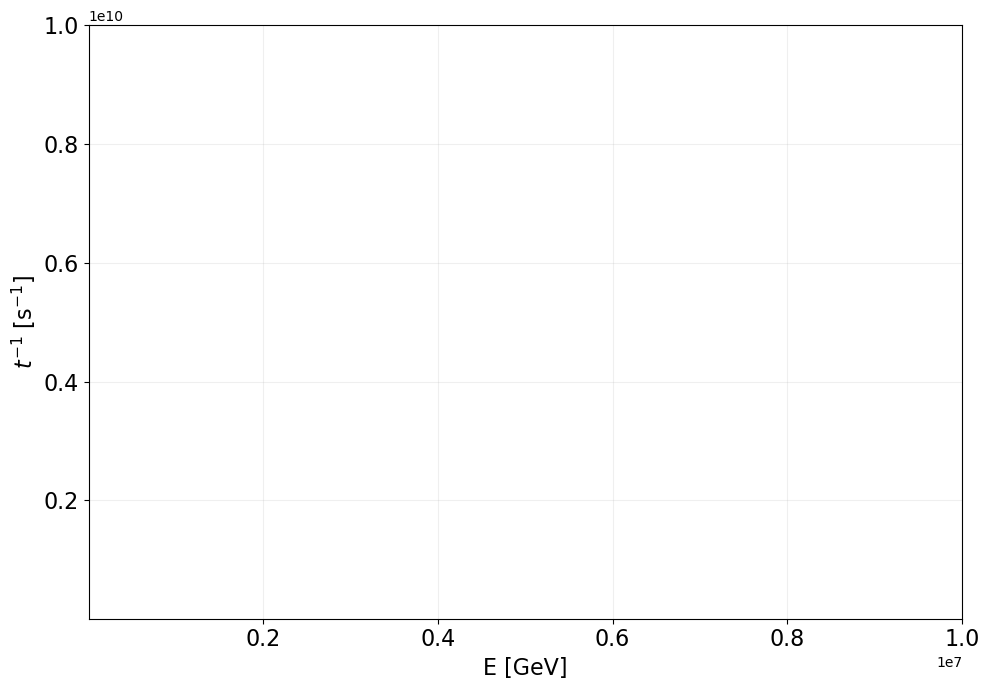

In [4]:
import matplotlib.pyplot as plt
import csv


mapa_z_acc = {}
try:
    with open('all_calculated_parameters.csv', 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            nome_fonte = row['Source_Name'].strip()
except FileNotFoundError:
    print("Aviso: O arquivo 'all_calculated_parameters (4).csv' não foi encontrado.")

print("=== PLOTTING ALL PROCESSES (LINES & CUSTOM LIMITS) ===")

# ======================================================================
# 1. BLOCO DE CONFIGURAÇÃO DAS FONTES
# ======================================================================
fontes_config = {
    "LEDA 55267": ["0.40", "0.63"],
    "LEDA 58287": ["0.40", "0.63"],
    "TOL 1326–379": ["0.40", "0.63"], 
    "Cen A": [""],
                  
}

# Mapa de Estilos de Linha (Distância -> Estilo)
style_map = {
    '0.40': '-',      
    '0.63': '--',     
    '': '-.'      
}


config_ele = {
    'acc':   {'title': 'Acceleration Rate',      'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc', 'loc_fr1': 'lower left',  'loc_fr0': 'upper right'},
    'sync':  {'title': 'Synchrotron Cooling',    'xlim': (1e-3, 1e1), 'ylim': (1e-3, 1e1), 'csv_col': 'rate_sync','loc_fr1': 'lower right',  'loc_fr0': 'upper left'},
    'brems': {'title': 'Bremsstrahlung Cooling', 'xlim': (1e-3, 1e5), 'ylim': (1e-9, 1e-6), 'csv_col': 'rate_bremss','loc_fr1': 'upper left',  'loc_fr0': 'lower right'},
    'ic':    {'title': 'Inverse Compton Cooling','xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2), 'csv_col': 'rate_ic_1','loc_fr1': 'upper left',  'loc_fr0': 'lower right'},
    'shear': {'title': 'Shear Acceleration',     'xlim': (1e0, 1e5), 'ylim': (1e-12, 1e-8), 'csv_col': 'Shear','loc_fr1': 'lower right',  'loc_fr0': 'upper left'},
    'esc':   {'title': 'Escape Rate',            'xlim': (1e3, 1e6), 'ylim': (1e8, 1e11), 'csv_col': 'ESC','loc_fr1': 'upper right',  'loc_fr0': 'lower left'}
}

config_pro = {
    'acc':   {'title': 'Acceleration Rate',      'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc','loc_fr1': 'upper right',  'loc_fr0': 'lower left'},
    'sync':  {'title': 'Synchrotron Cooling',    'xlim': (1e1, 1e6),  'ylim': (1e-11, 1e-8), 'csv_col': 'rate_sync','loc_fr1': 'lower right',  'loc_fr0': 'upper left'},
    'pp':    {'title': 'PP Collision Rate',      'xlim': (5e0, 1e9),  'ylim': (1e-9, 1e-6),'csv_col': 'rate_pp','loc_fr1': 'upper left',  'loc_fr0': 'lower right'},
    'pg':    {'title': r'P$\gamma$ Cooling',     'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1), 'csv_col': 'rate_pg','loc_fr1': 'upper left',  'loc_fr0': 'lower right'},
    'shear': {'title': 'Shear Acceleration',     'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8), 'csv_col': 'Shear','loc_fr1': 'upper left',  'loc_fr0': 'lower right'},
    'esc':   {'title': 'Escape Rate',            'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10), 'csv_col': 'ESC','loc_fr1': 'lower left',  'loc_fr0': 'upper right'}
}


def process_and_plot(particle_type, config_processos, e_col_name):
    master_data = {}
    
    for base_name, distancias in fontes_config.items():
        master_data[base_name] = {}
        for dist in distancias:
            filename = f"data/{base_name} {dist}_{particle_type}.csv" if dist != "" else f"data/{base_name}_{particle_type}.csv"
            
            master_data[base_name][dist] = {'E': []}
            for key in config_processos.keys():
                master_data[base_name][dist][key] = []
            
            try:
                with open(filename, 'r') as f:
                    reader = csv.DictReader(f)
                    for row in reader:
                        master_data[base_name][dist]['E'].append(float(row[e_col_name]))
                        for proc_key, p_conf in config_processos.items():
                            master_data[base_name][dist][proc_key].append(float(row[p_conf['csv_col']]))
            except FileNotFoundError:
                del master_data[base_name][dist] # Remove do plot se o arquivo não existe

    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for proc_key, p_config in config_processos.items():
        plt.figure(figsize=(10, 7))
        
        color_idx = 0
        base_name_colors = {}
        
        for base_name, dists_dict in master_data.items():
            if not dists_dict: continue 
            
            if base_name not in base_name_colors:
                base_name_colors[base_name] = default_colors[color_idx % len(default_colors)]
                color_idx += 1
            
            cor = base_name_colors[base_name]
            
            for dist, dados in dists_dict.items():
                if not dados['E']: continue
                
                ls = style_map.get(dist, '-')
                
                lw = 3.5 if dist == 'Unica' else 2.0
                
                nome_busca = f"{base_name} {dist}".strip()
                
                if nome_busca in mapa_z_acc:
                    valor_z = mapa_z_acc[nome_busca]
                    label = f"{base_name} ( {valor_z} Rg)"
                else:
                    label = f"{base_name} ({dist})" if dist != '' else base_name
                
                plt.loglog(dados['E'], dados[proc_key], 
                           label=label, color=cor, linestyle=ls, linewidth=lw)
        
        #plt.title(f"{p_config['title']} ({particle_type.capitalize()})", fontsize=15, fontweight='bold')
        plt.xlabel('E [GeV]', fontsize=16)
        plt.ylabel(r'$t^{-1}$ [s$^{-1}$]', fontsize=16)
        
        plt.xlim(p_config['xlim'])
        plt.ylim(p_config['ylim'])
        
        plt.tick_params(axis='both', which='major', labelsize=16)
        
        handles, labels = plt.gca().get_legend_handles_labels()

        h_fr1, l_fr1 = [], []
        h_fr0, l_fr0 = [], []

        # Separa as linhas baseado no nome que aparece na legenda
        for h, l in zip(handles, labels):
            if "Cen A" in l or "NGC 1275" in l:
                h_fr1.append(h)
                l_fr1.append(l)
            else:
                h_fr0.append(h)
                l_fr0.append(l)

        # Busca as posições escolhidas no dicionário (usa 'best' como padrão de segurança)
        pos_fr1 = p_config.get('loc_fr1', 'best')
        pos_fr0 = p_config.get('loc_fr0', 'best')

        # Desenha a primeira legenda (FR I) 
        if h_fr1:
            leg_fr1 = plt.legend(h_fr1, l_fr1, title='FR I', loc=pos_fr1, fontsize=12, frameon=False)
            leg_fr1.get_title().set_fontweight('bold')
            plt.gca().add_artist(leg_fr1)

        # Desenha a segunda legenda (FR0)
        if h_fr0:
            leg_fr0 = plt.legend(h_fr0, l_fr0, title='FR0', loc=pos_fr0, fontsize=12, ncol=2,frameon=False)
            leg_fr0.get_title().set_fontweight('bold')
            
        plt.grid(True, which="major", ls="-", alpha=0.2)
        plt.tight_layout()
        
        nome_arquivo = f"image/{particle_type.capitalize()}_{proc_key}_linhas.png"
        plt.savefig(nome_arquivo, dpi=300)
        plt.show() 
        plt.close()


process_and_plot(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')

process_and_plot(particle_type='protons', config_processos=config_pro, e_col_name='E_prime_GeV')


=== PLOTTING POPULATION (100+ SOURCES WITH EXTERNAL LEGEND) ===
[ELECTRONS] Encontradas 46 fontes. Iniciando leitura...


/tmp/ipykernel_1482046/3274973932.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


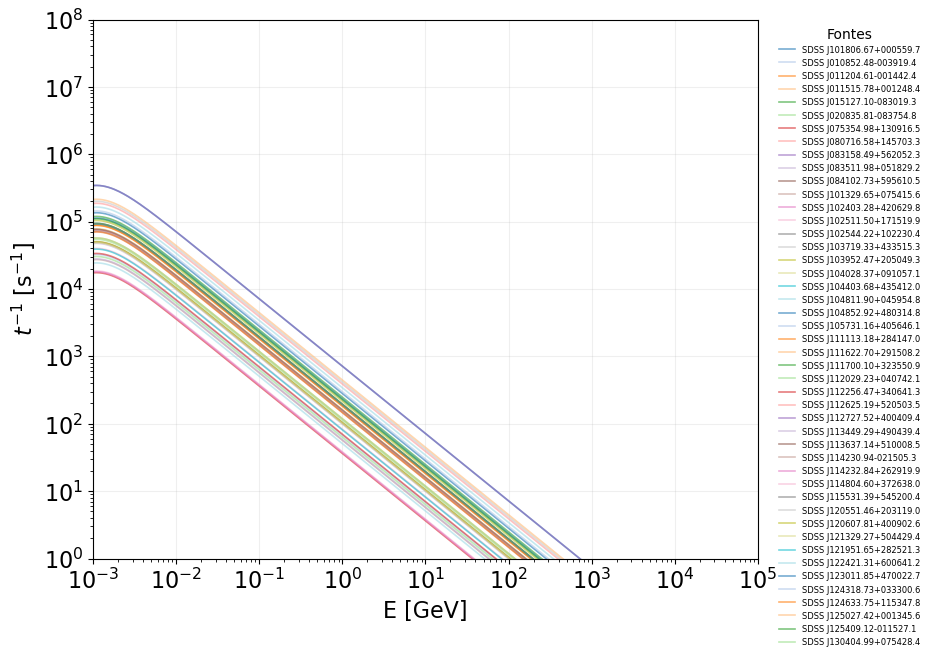

  -> Salvo: image/Electrons_acc_n_population.png (46 linhas plotadas)


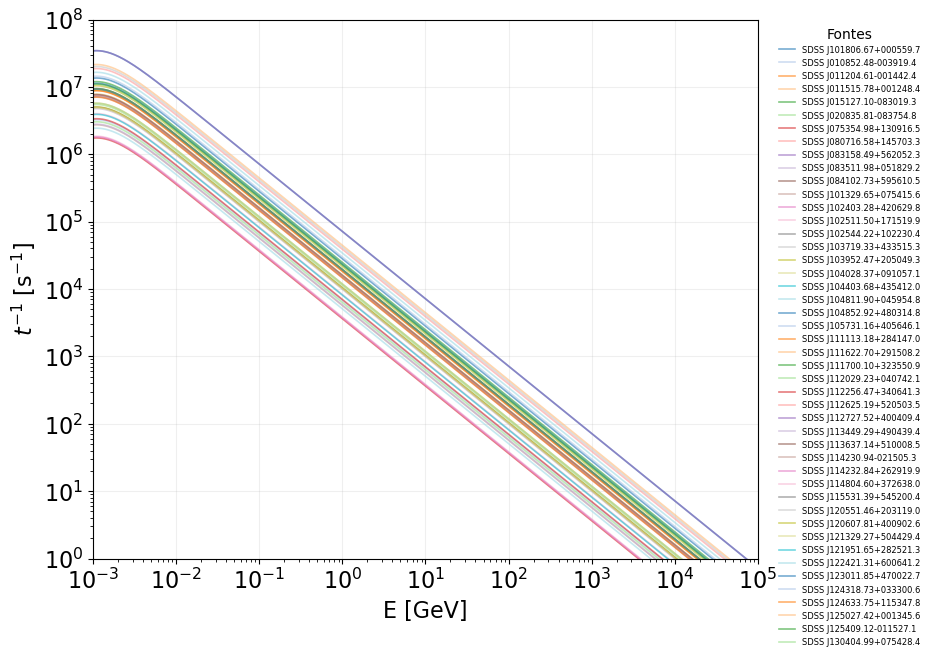

  -> Salvo: image/Electrons_acc_n2_population.png (46 linhas plotadas)


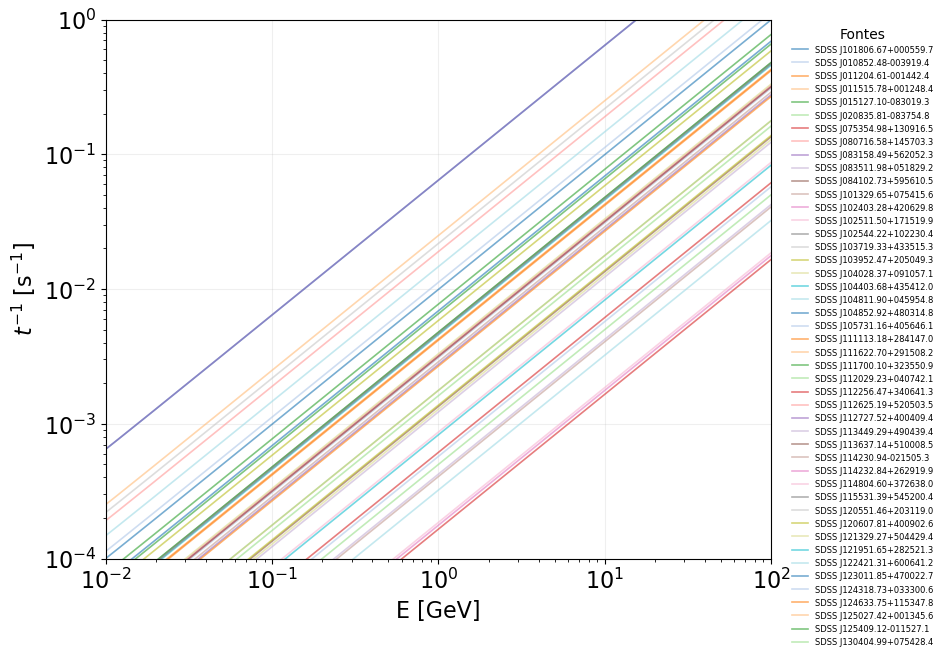

  -> Salvo: image/Electrons_sync_population.png (46 linhas plotadas)


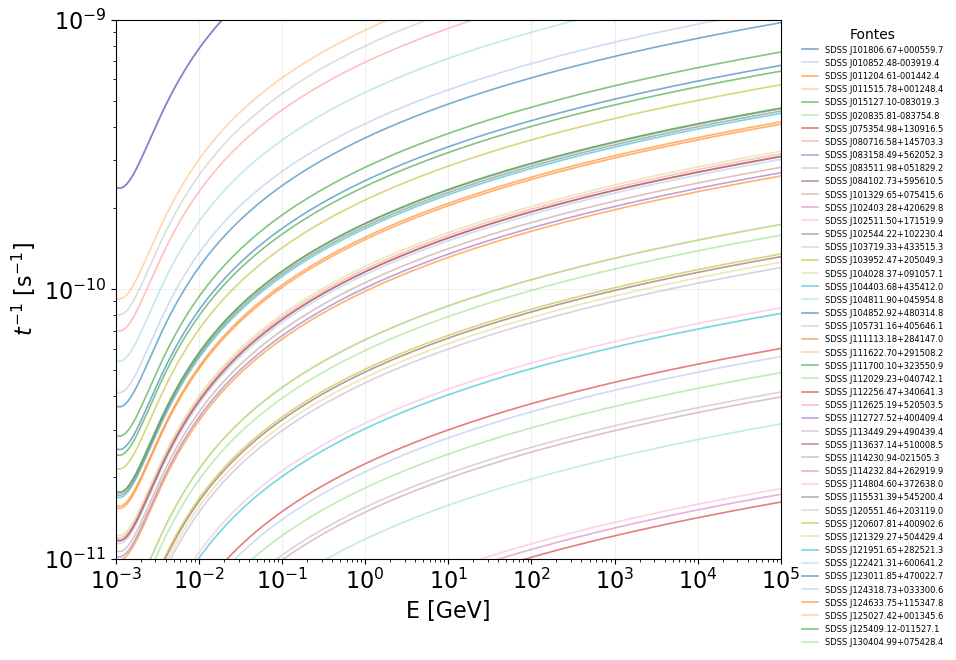

  -> Salvo: image/Electrons_brems_population.png (46 linhas plotadas)


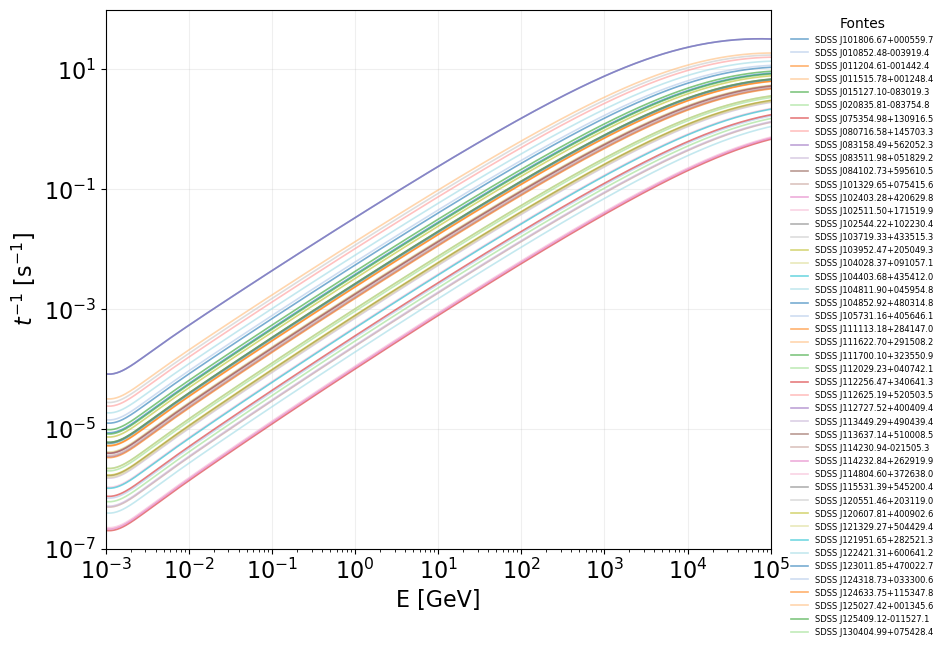

  -> Salvo: image/Electrons_ic_population.png (46 linhas plotadas)


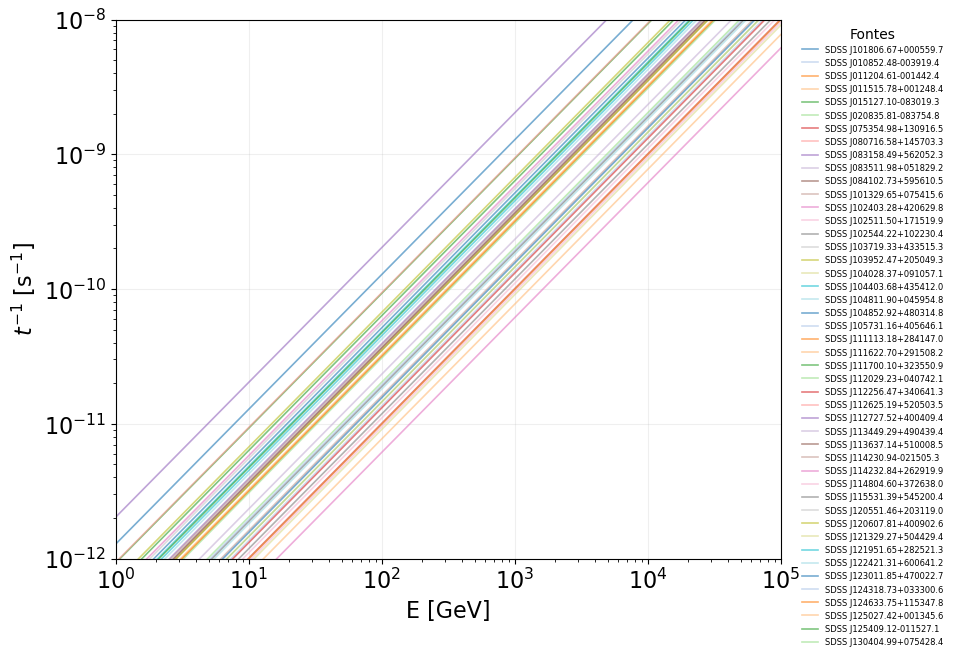

  -> Salvo: image/Electrons_shear_population.png (46 linhas plotadas)


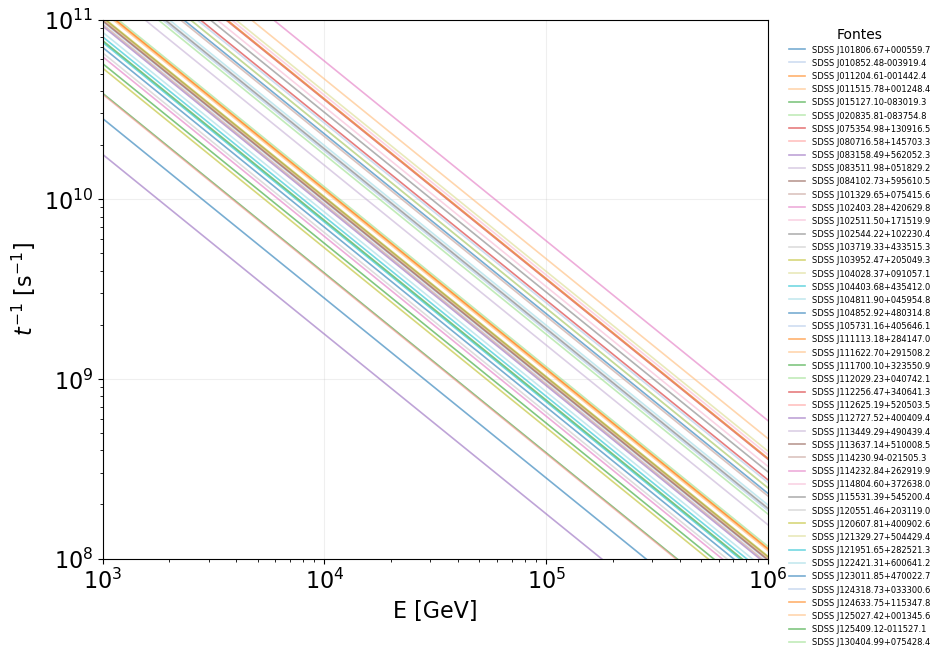

  -> Salvo: image/Electrons_esc_population.png (46 linhas plotadas)
[PROTONS] Encontradas 46 fontes. Iniciando leitura...


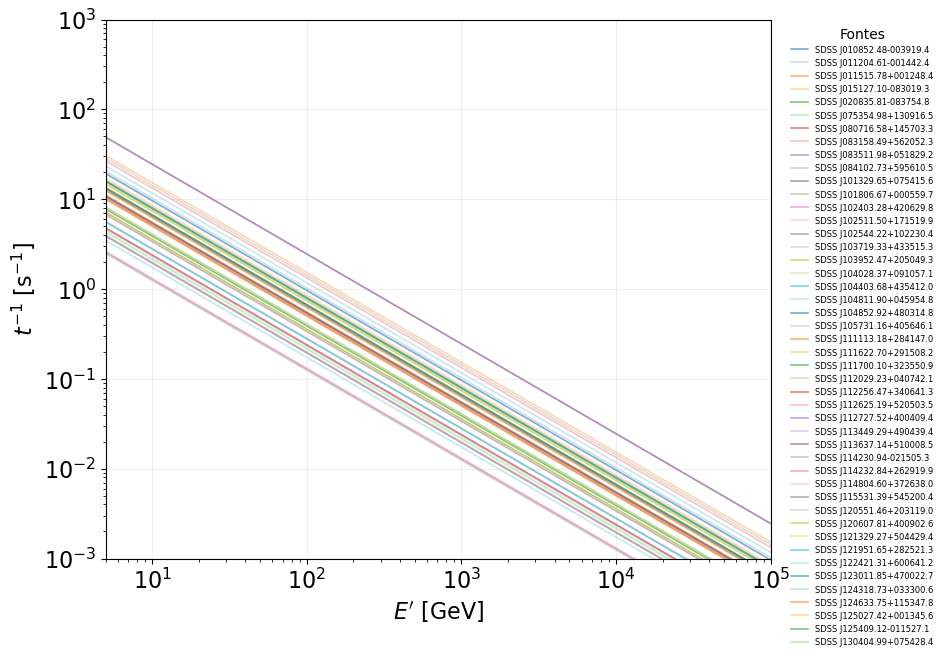

  -> Salvo: image/Protons_acc_n_population.png (46 linhas plotadas)


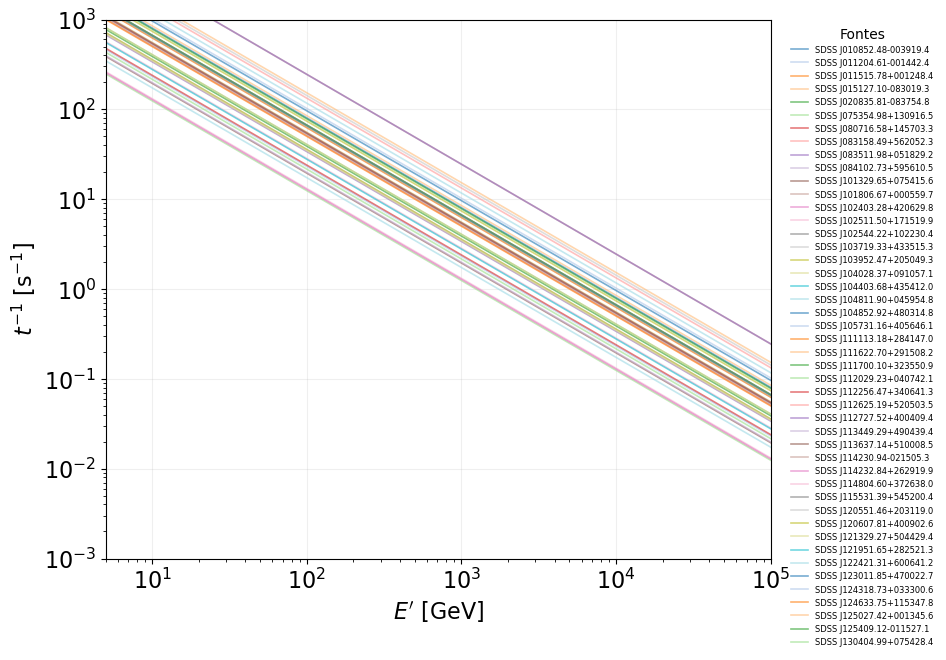

  -> Salvo: image/Protons_acc_n2_population.png (46 linhas plotadas)


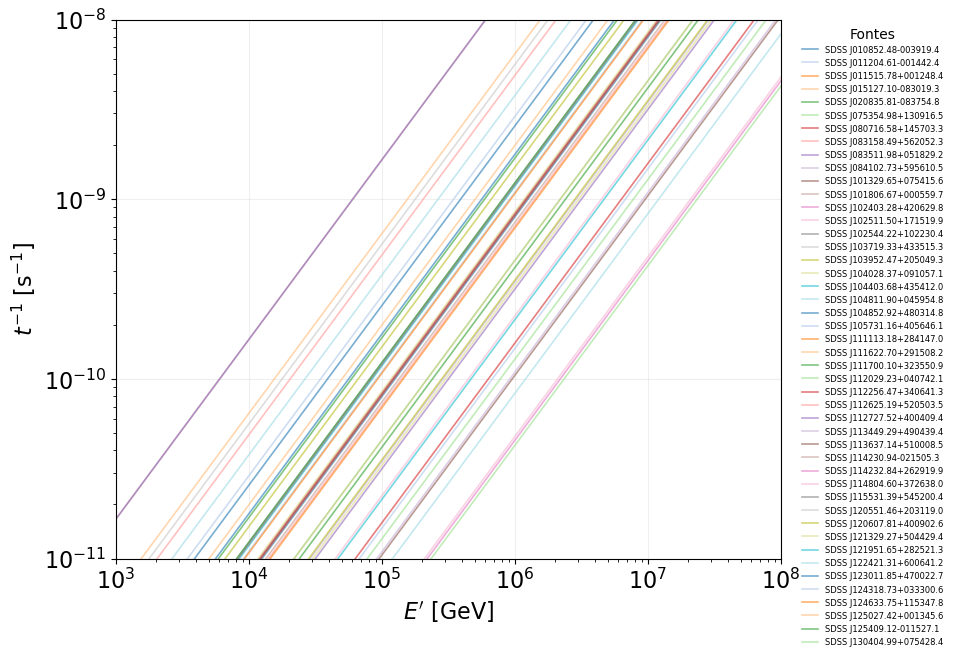

  -> Salvo: image/Protons_sync_population.png (46 linhas plotadas)


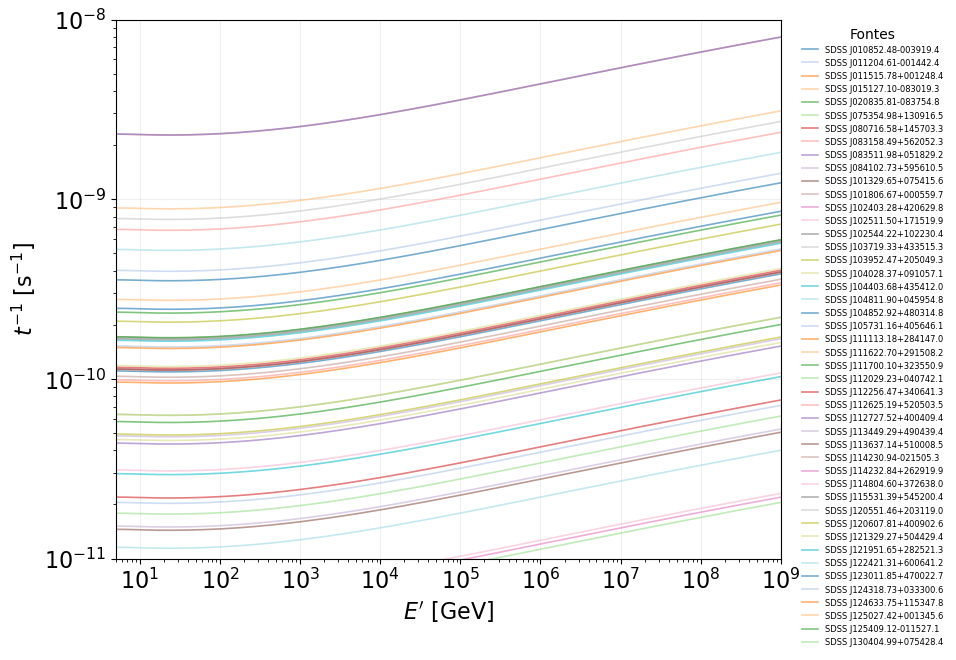

  -> Salvo: image/Protons_pp_population.png (46 linhas plotadas)


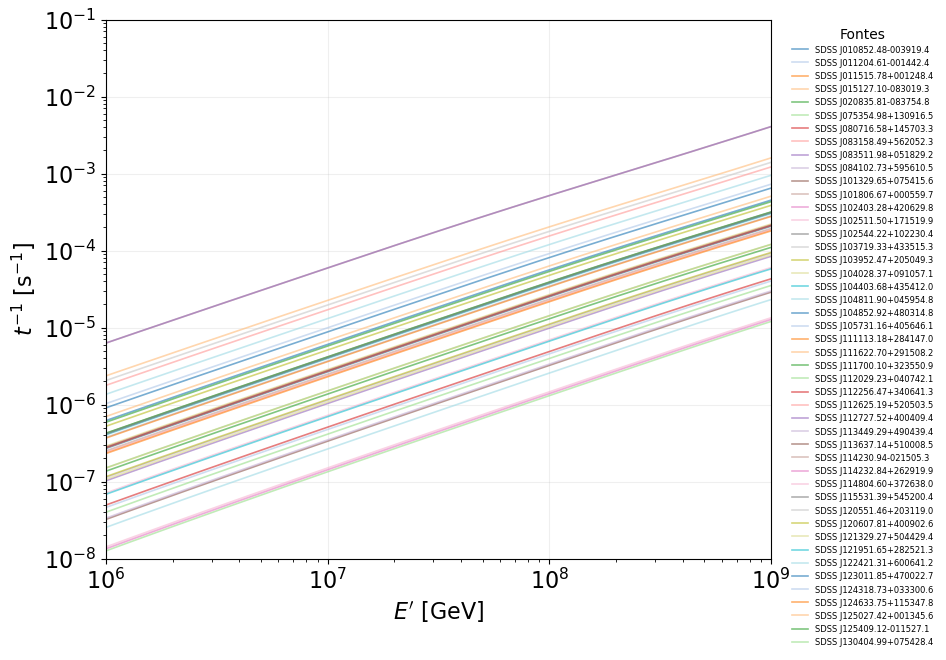

  -> Salvo: image/Protons_pg_population.png (46 linhas plotadas)


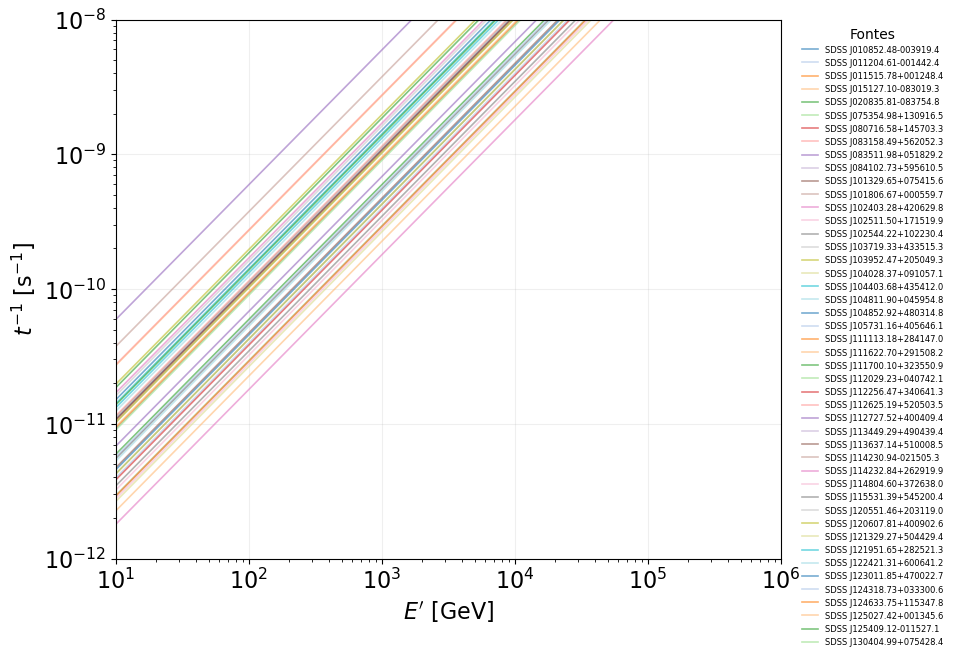

  -> Salvo: image/Protons_shear_population.png (46 linhas plotadas)


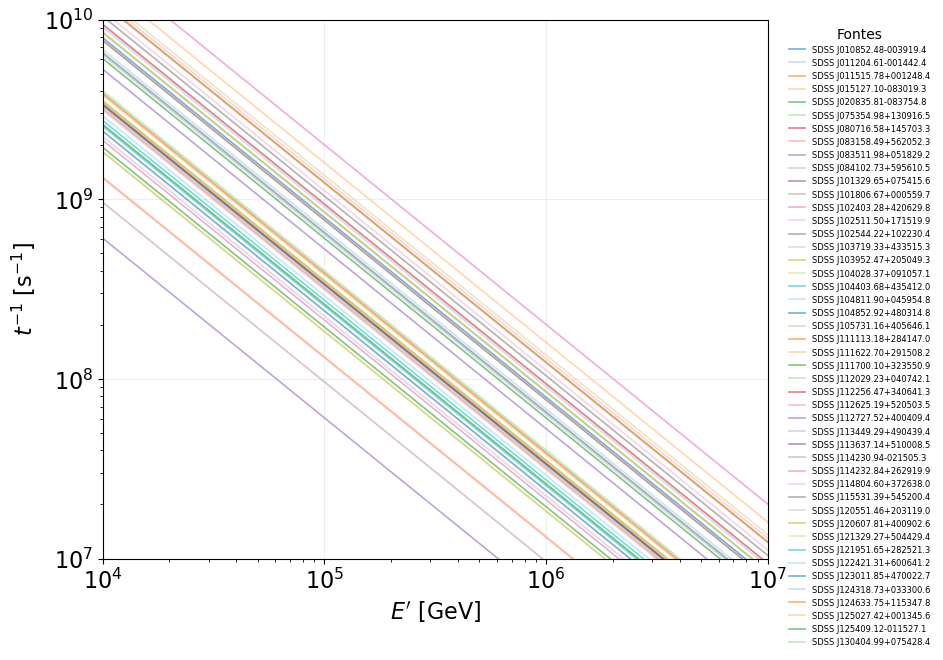

  -> Salvo: image/Protons_esc_population.png (46 linhas plotadas)


In [8]:
import matplotlib.pyplot as plt
import csv
import os
import glob
import matplotlib.cm as cm

print("=== PLOTTING POPULATION (100+ SOURCES WITH EXTERNAL LEGEND) ===")

# ======================================================================
# 1. CONFIGURAÇÃO DOS PROCESSOS
# ======================================================================
config_ele = {
    'acc_n':   {'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc'}, 
    'acc_n2':  {'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e-2, 1e2), 'ylim': (1e-4, 1e0), 'csv_col': 'rate_sync'},
    'brems':   {'xlim': (1e-3, 1e5), 'ylim': (1e-11, 1e-9),'csv_col': 'rate_bremss'},
    'ic':      {'xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2), 'csv_col': 'rate_ic_1'},
    'shear':   {'xlim': (1e0, 1e5),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'xlim': (1e3, 1e6),  'ylim': (1e8, 1e11), 'csv_col': 'ESC'}
}

config_pro = {
    'acc_n':   {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc'},
    'acc_n2':  {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e3, 1e8),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_sync'},
    'pp':      {'xlim': (5e0, 1e9),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_pp'},
    'pg':      {'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1),'csv_col': 'rate_pg'},
    'shear':   {'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10), 'csv_col': 'ESC'}
}

def process_and_plot_population(particle_type, config_processos, e_col_name):
    padrao = f"data/*_{particle_type}.csv"
    arquivos = glob.glob(padrao)
    
    if not arquivos:
        print(f"Nenhum arquivo encontrado para {particle_type} na pasta 'data/'.")
        return
        
    print(f"[{particle_type.upper()}] Encontradas {len(arquivos)} fontes. Iniciando leitura...")

    master_data = {}
    
    # ======================================================================
    # 2. LER TODOS OS ARQUIVOS COM DIAGNÓSTICO DE ERROS
    # ======================================================================
    for filepath in arquivos:
        nome_arquivo = os.path.basename(filepath)
        base_name = nome_arquivo.replace(f"_{particle_type}.csv", "")
        
        master_data[base_name] = {'E': []}
        for key in config_processos.keys():
            master_data[base_name][key] = []
            
        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            cabecalhos = reader.fieldnames
            
            # 1. Verifica se a coluna de Energia existe no arquivo
            if cabecalhos is None or e_col_name not in cabecalhos:
                print(f"  -> ERRO CRÍTICO: Coluna de energia '{e_col_name}' não existe em {nome_arquivo}!")
                continue # Pula este arquivo inteiro
            
            # 2. Verifica quais colunas de processos realmente existem neste CSV
            processos_validos = []
            for proc_key, p_conf in config_processos.items():
                col_name = p_conf['csv_col']
                if col_name in cabecalhos:
                    processos_validos.append(proc_key)
                else:
                    # Avisa na tela qual coluna está faltando e com qual nome ele procurou
                    print(f"  -> AVISO: Coluna '{col_name}' faltando no arquivo {nome_arquivo}. Processo '{proc_key}' não será plotado para esta fonte.")

            # 3. Lê as linhas garantindo que E e t^-1 tenham o mesmo tamanho
            for row in reader:
                try:
                    e_val = float(row[e_col_name])
                    
                    # Lê os valores temporariamente para garantir que não vai dar erro
                    temp_vals = {}
                    for proc_key in processos_validos:
                        col_name = config_processos[proc_key]['csv_col']
                        temp_vals[proc_key] = float(row[col_name])
                    
                    # Se chegou até aqui sem dar erro (sem encontrar strings vazias), salva nas listas finais
                    master_data[base_name]['E'].append(e_val)
                    for proc_key in processos_validos:
                        master_data[base_name][proc_key].append(temp_vals[proc_key])
                        
                except ValueError:
                    # Pula silenciosamente apenas linhas com texto/espaços vazios no meio dos números
                    pass 

    os.makedirs("image", exist_ok=True)
    import matplotlib.cm as cm
    cmap = cm.get_cmap('tab20')
    cores = cmap.colors

    # ======================================================================
    # 3. PLOTAR OS GRÁFICOS
    # ======================================================================
    for proc_key, p_config in config_processos.items():
        plt.figure(figsize=(14, 7))
        
        fontes_validas = 0
        for i, (base_name, dados) in enumerate(master_data.items()):
            # Só plota se tiver dados de energia E dados daquele processo específico
            if not dados['E'] or not dados[proc_key]:
                continue
            
            cor_atual = cores[i % len(cores)]
            
            plt.loglog(dados['E'], dados[proc_key], color=cor_atual, alpha=0.6, 
                       linewidth=1.2, label=base_name)
            fontes_validas += 1
            
        # Se nenhuma fonte teve dados para este processo, avisa e não salva gráfico em branco
        if fontes_validas == 0:
            print(f"  -> {proc_key}: Nenhuma fonte plotada (verifique os avisos de colunas faltando acima).")
            plt.close()
            continue

        xlabel_str = 'E [GeV]' if particle_type == 'electrons' else r'$E^\prime$ [GeV]'
        plt.xlabel(xlabel_str, fontsize=16)
        plt.ylabel(r'$t^{-1}$ [s$^{-1}$]', fontsize=16)
        
        plt.xlim(p_config['xlim'])
        plt.ylim(p_config['ylim'])
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.grid(True, which="major", ls="-", alpha=0.2)
        
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                   fontsize=6, ncol=1, frameon=False, title="Fontes")
        
        plt.subplots_adjust(right=0.6) 
        
        nome_arquivo = f"image/{particle_type.capitalize()}_{proc_key}_population.png"
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  -> Salvo: {nome_arquivo} ({fontes_validas} linhas plotadas)")

process_and_plot_population(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')
process_and_plot_population(particle_type='protons', config_processos=config_pro, e_col_name='E_prime_GeV')

In [13]:
import matplotlib.pyplot as plt
import csv
import os
import glob
import matplotlib.cm as cm
import math

print("=== PLOTTING COMBINED FIGURE FOR POPULATION ===")

# ======================================================================
# 1. CONFIGURAÇÃO DOS PROCESSOS (7 Processos no total)
# ======================================================================
config_ele = {
    'acc_n':   {'title': 'Acceleration Rate (n)',  'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8),   'csv_col': 'rate_acc_n'}, 
    'acc_n2':  {'title': 'Acceleration Rate (n2)', 'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8),   'csv_col': 'rate_acc_n2'},
    'sync':    {'title': 'Synchrotron Cooling',    'xlim': (1e-3, 1e1), 'ylim': (1e-3, 1e1),  'csv_col': 'rate_sync'},
    'brems':   {'title': 'Bremsstrahlung Cooling', 'xlim': (1e-3, 1e5), 'ylim': (1e-9, 1e-6), 'csv_col': 'rate_bremss'},
    'ic':      {'title': 'Inverse Compton Cooling','xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2),  'csv_col': 'rate_ic_1'},
    'shear':   {'title': 'Shear Acceleration',     'xlim': (1e0, 1e5),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'title': 'Escape Rate',            'xlim': (1e3, 1e6),  'ylim': (1e8, 1e11),  'csv_col': 'ESC'}
}

config_pro = {
    'acc_n':   {'title': 'Acceleration Rate (n)',  'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3),  'csv_col': 'rate_acc_n'},
    'acc_n2':  {'title': 'Acceleration Rate (n2)', 'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3),  'csv_col': 'rate_acc_n2'},
    'sync':    {'title': 'Synchrotron Cooling',    'xlim': (1e1, 1e6),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_sync'},
    'pp':      {'title': 'PP Collision Rate',      'xlim': (5e0, 1e9),  'ylim': (1e-9, 1e-6), 'csv_col': 'rate_pp'},
    'pg':      {'title': r'P$\gamma$ Cooling',     'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1), 'csv_col': 'rate_pg'},
    'shear':   {'title': 'Shear Acceleration',     'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'title': 'Escape Rate',            'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10),  'csv_col': 'ESC'}
}

def gerar_grande_figura_combinada(particle_type, config_processos, e_col_name):
    padrao = f"data/*_{particle_type}.csv"
    arquivos = glob.glob(padrao)
    
    if not arquivos:
        print(f"Nenhum arquivo encontrado para {particle_type} na pasta 'data/'.")
        return
        
    print(f"\n[{particle_type.upper()}] Montando figura combinada para {len(arquivos)} fontes...")

    # ======================================================================
    # 2. LEITURA SEGURA DOS DADOS
    # ======================================================================
    master_data = {}
    for filepath in arquivos:
        base_name = os.path.basename(filepath).replace(f"_{particle_type}.csv", "")
        master_data[base_name] = {'E': []}
        for key in config_processos.keys():
            master_data[base_name][key] = []
            
        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            cabecalhos = reader.fieldnames
            
            if cabecalhos is None or e_col_name not in cabecalhos:
                continue 
            
            processos_validos = [pk for pk, pc in config_processos.items() if pc['csv_col'] in cabecalhos]
            
            for row in reader:
                try:
                    e_val = float(row[e_col_name])
                    temp_vals = {pk: float(row[config_processos[pk]['csv_col']]) for pk in processos_validos}
                    
                    master_data[base_name]['E'].append(e_val)
                    for pk in processos_validos:
                        master_data[base_name][pk].append(temp_vals[pk])
                except ValueError:
                    pass 

    os.makedirs("image", exist_ok=True)
    cmap = cm.get_cmap('tab20')
    cores = cmap.colors

    # ======================================================================
    # 3. CRIAÇÃO DINÂMICA DA MATRIZ DE SUBPLOTS
    # ======================================================================
    n_plots = len(config_processos)
    ncols = 3
    nrows = math.ceil(n_plots / ncols) # Para 7 processos, será 3x3 (9 painéis)

    # Aumentamos o figsize para acomodar os 3 painéis de largura e a legenda extra na direita
    fig, axes_matrix = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows))
    axes = axes_matrix.flatten()
    
    fontes_plotadas_para_legenda = []

    for idx, (proc_key, p_config) in enumerate(config_processos.items()):
        ax = axes[idx]
        
        for i, (base_name, dados) in enumerate(master_data.items()):
            if not dados['E'] or not dados[proc_key]:
                continue
            
            cor_atual = cores[i % len(cores)]
            linha, = ax.loglog(dados['E'], dados[proc_key], color=cor_atual, alpha=0.6, 
                               linewidth=1.2, label=base_name)
            
            # Guardamos o objeto 'linha' da primeira fonte que passar aqui para compor a legenda global depois
            if idx == 0: 
                fontes_plotadas_para_legenda.append((linha, base_name))

        ax.set_title(p_config['title'], fontsize=14, fontweight='bold')
        xlabel_str = 'E [GeV]' if particle_type == 'electrons' else r'$E^\prime$ [GeV]'
        ax.set_xlabel(xlabel_str, fontsize=12)
        ax.set_ylabel(r'$t^{-1}$ [s$^{-1}$]', fontsize=12)
        
        ax.set_xlim(p_config['xlim'])
        ax.set_ylim(p_config['ylim'])
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, which="major", ls="-", alpha=0.2)

    # Ocultar painéis sobressalentes (ex: gráficos 8 e 9 no grid 3x3)
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)

    # ======================================================================
    # 4. LEGENDA GLOBAL E SALVAMENTO
    # ======================================================================
    # Em vez de pôr a legenda no eixo (ax), colocamos na figura inteira (fig)
    if fontes_plotadas_para_legenda:
        linhas = [f[0] for f in fontes_plotadas_para_legenda]
        nomes = [f[1] for f in fontes_plotadas_para_legenda]
        
        # Ajusta dinamicamente as colunas da legenda para não estourar a tela
        num_cols = max(2, len(nomes) // 25) 
        
        fig.legend(linhas, nomes, loc='center right', bbox_to_anchor=(0.98, 0.5), 
                   fontsize=8, ncol=num_cols, frameon=False, title="Fontes (Todas)")

    plt.tight_layout()
    # O tight_layout comprime os subplots. Esse subplots_adjust "espreme" os gráficos
    # para a esquerda para abrir espaço real para a legenda global na direita.
    plt.subplots_adjust(right=0.85)
    
    nome_grande_arquivo = f"image/{particle_type.capitalize()}_TODOS_PROCESSOS_COMBINADOS.png"
    plt.savefig(nome_grande_arquivo, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  -> Imagem combinada gerada com sucesso: {nome_grande_arquivo}")

gerar_grande_figura_combinada(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')
gerar_grande_figura_combinada(particle_type='protons', config_processos=config_pro, e_col_name='E_prime_GeV')

=== PLOTTING COMBINED FIGURE FOR POPULATION ===

[ELECTRONS] Montando figura combinada para 17 fontes...


/tmp/ipykernel_31683/3663270260.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


  -> Imagem combinada gerada com sucesso: image/Electrons_TODOS_PROCESSOS_COMBINADOS.png

[PROTONS] Montando figura combinada para 17 fontes...
  -> Imagem combinada gerada com sucesso: image/Protons_TODOS_PROCESSOS_COMBINADOS.png


In [6]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

print("\n" + "="*60)
print("-> Carregando dados dos arquivos CSV para o gráfico...")
print("="*60)

all_fluxes_plot = {}
E_nu_GeV_plot = [] 

for file in os.listdir('data'):
    if file.endswith('_neutrino_fluxes.csv'):
        nome_fonte = file.replace('_neutrino_fluxes.csv', '').replace('_', ' ')
        flux_pp_list, flux_pg_list, E_nu_list = [], [], []
        
        with open(os.path.join('data', file), mode='r', encoding='utf-8') as f:
            reader = csv.reader(f)
            next(reader) 
            for row in reader:
                E_nu_list.append(float(row[0]))
                flux_pp_list.append(float(row[1]))
                flux_pg_list.append(float(row[2]))
        
        all_fluxes_plot[nome_fonte] = {'pp': np.array(flux_pp_list), 'pg': np.array(flux_pg_list)}
        if len(E_nu_GeV_plot) == 0: E_nu_GeV_plot = np.array(E_nu_list)

print(f"Fontes carregadas com sucesso: {list(all_fluxes_plot.keys())}")

plt.figure(figsize=(12, 8))
colores = cm.tab10(np.linspace(0, 1, len(all_fluxes_plot)))

for idx, (name, fluxes) in enumerate(all_fluxes_plot.items()):
    color = colores[idx]
    plt.loglog(E_nu_GeV_plot, fluxes['pp'], color=color, linestyle='-', linewidth=2.5, label=f'{name} ($pp$)')
    plt.loglog(E_nu_GeV_plot, fluxes['pg'], color=color, linestyle='--', linewidth=2.5, label=f'{name} ($p\gamma$)')

# 1. Curva de Sensibilidade do KM3NeT/ARCA
E_km3_GeV = np.array([1e2, 1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6, 3e6, 1e7, 1e8])
Sens_km3 = np.array([1e-6, 4e-8, 1e-8, 3e-9, 1.2e-9, 8e-10, 8e-10, 1.2e-9, 2.5e-9, 8e-9, 4e-8])
interp_km3 = interp1d(np.log10(E_km3_GeV), np.log10(Sens_km3), kind='cubic', bounds_error=False, fill_value=np.nan)
E_plot_km3 = np.logspace(2, 7.5, 100)
Sens_plot_km3 = 10**interp_km3(np.log10(E_plot_km3))
plt.loglog(E_plot_km3, Sens_plot_km3, color='gray', linestyle='dotted', linewidth=2, label='KM3NeT/ARCA Sensitivity')

# 2. Curva de Sensibilidade do IceCube
energia_nu_TeV = np.array([0.1, 0.316, 1.0, 3.16, 10.0, 31.6, 100.0, 316.2, 1000.0, 3162.2, 10000.0])
sensibilidade_icecube_TeV = np.array([2.0e-11, 4.0e-12, 1.0e-12, 4.5e-13, 2.5e-13, 1.8e-13, 1.5e-13, 1.8e-13, 3.0e-13, 6.0e-13, 2.5e-12])
E_ice_GeV = energia_nu_TeV * 1000
Sens_ice_GeV = sensibilidade_icecube_TeV * 1000
interp_ice = interp1d(np.log10(E_ice_GeV), np.log10(Sens_ice_GeV), kind='cubic', bounds_error=False, fill_value=np.nan)
Sens_plot_ice = 10**interp_ice(np.log10(E_plot_km3))
plt.loglog(E_plot_km3, Sens_plot_ice, color='black', linestyle='-.', linewidth=2, label='IceCube Sensitivity')

# Estilização
plt.xlabel(r'$E_\nu$ [GeV]', fontsize=15)
plt.ylabel(r'$E_\nu^2 d\Phi_\nu/dE_\nu$ [GeV cm$^{-2}$ s$^{-1}$]', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.ylim(1e-15, 1e-7) 
plt.xlim(100, 1e7)

# Lógica de Legendas Múltiplas
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
handles_pp, labels_pp, handles_pg, labels_pg, handles_sens, labels_sens = [], [], [], [], [], []

for h, l in zip(handles, labels):
    if 'pp' in l:
        handles_pp.append(h)
        labels_pp.append(l.replace(' ($pp$)', '')) 
    elif 'gamma' in l or r'\gamma' in l:
        handles_pg.append(h)
        labels_pg.append(l.replace(' ($p\gamma$)', '')) 
    elif 'Sensitivity' in l:
        handles_sens.append(h)
        labels_sens.append(l)

leg_pp = ax.legend(handles_pp, labels_pp, loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=False, fontsize=12)
leg_pp.get_title().set_fontweight('bold')
ax.add_artist(leg_pp)

leg_pg = ax.legend(handles_pg, labels_pg, loc='upper center', bbox_to_anchor=(0.45, 0.98), frameon=False, fontsize=12)
leg_pg.get_title().set_fontweight('bold')
ax.add_artist(leg_pg)

leg_sens = ax.legend(handles_sens, labels_sens, loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=False, fontsize=12)
leg_sens.get_title().set_fontweight('bold')
ax.add_artist(leg_sens)

linha_pp = mlines.Line2D([], [], color='black', linestyle='-', linewidth=2.5, label=' $pp$')
linha_pg = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2.5, label='$p\gamma$')
leg_estilos = ax.legend(handles=[linha_pp, linha_pg], loc='lower left', bbox_to_anchor=(0.02, 0.02), frameon=False, fontsize=12)

plt.tight_layout()
os.makedirs("Image", exist_ok=True)
plot_filename = "Image/neutrino_flux_Population.png"
plt.savefig(plot_filename, dpi=200)
print(f"-> Plotagem salva com sucesso em '{plot_filename}'!")

plt.show()


-> Carregando dados dos arquivos CSV para o gráfico...
Fontes carregadas com sucesso: []


NameError: name 'interp1d' is not defined

<Figure size 1200x800 with 0 Axes>